# MVP — Machine Learning & Analytics

**Nome:** João Victor Amaral dos Santos

**Matrícula:** 4052025002072

**Data:** 30/05/2026  

**Dataset:** [Status do INR em Pacientes em Uso de Varfarina](https://raw.githubusercontent.com/eng-jvamaral/MVPs-PosGrad-PUCRJ/refs/heads/main/PUCRJ-MVP-ML-VARF/warfarin_inr.csv)

**Tipo de problema:** Classificação Supervisionada

**Tempo estimado de execução completa do notebook:**

# 1. Definição do problema

## 1.1 Descrição do problema

O objeto de estudo deste trabalho é analisar um medicamento chamado Varfarina (Warfarin, em inglês). Esse medicamento é um anticoagulante, e é usado em tratamento de trombose venosa profunda, embolia pulmonar, acidente vascular cerebral (AVC) e infartos, além de proteger pacientes com próteses de válvulas cardíacas ou fibrilação atrial ([National Library of Medicine](https://www.ncbi.nlm.nih.gov/books/NBK470313/)).

De maneira bem rudimentar, o medicamento mantém o sangue numa viscosidade ideal, de modo que não esteja fino demais (facilidade de sangrar) ou grosso demais (facilidade de formar os coágulos). E esse equilíbrio é medido por um indicador numérico chamado INR pelos médicos. Se o INR está entre 2 e 3, está ideal; se é maior que 3, então o sangue está 'fino' demais, portanto fácil de sangrar e dificuldade de estancar o sangue, que são as hemorragias ([National Library of Medicine](https://www.ncbi.nlm.nih.gov/books/NBK470313/)).


O problema é que o que a pessoa come ou outros remédios que ela toma influenciam diretamente nesse indicador, pois a varfarina é muito sensível. Isso está relacionado a interações medicamentosas com outros princípios ativos (para os casos que outro tratamento paralelo que a pessoa faz) ou até mesmo com nutrientes dos alimentos, como a vitamina K, por exemplo.



## 1.2 Justificativa e motivação

Em **postos de saúde de pequeno porte**, onde está a maior parte dos pacientes em uso crônico de varfarina no SUS, não há farmacêutico clínico dedicado, o intervalo entre consultas é longo, e a triagem de risco depende exclusivamente da memória e do tempo do profissional. É exatamente nesse vão que um modelo de classificação tem espaço: para **sinalizar prioridade de reavaliação** a partir de variáveis simples que qualquer técnico de enfermagem coleta em triagem (idade, IMC, dieta autorrelatada, lista de medicamentos em uso) ou em conciliação medicamentosa.

O objetivo do trabalho, portanto, **não é substituir o julgamento clínico do farmacêutico ou do médico**, é entregar um MVP que consome os dados coletados e o modelo classifica a condição, priorizando a fila de triagem para acompanhamento seja nutricional, farmacêutico ou médico. Além de melhorar a qualidade do atendimento e da orientação aos pacientes.

### Sobre a escolha do tema e do dado

O dataset é **sintético, gerado com auxílio de LLM** a partir da literatura científica revisada (Bushra et al., 2011; IWPC; Sanoski & Bauman, 2002; Battistella, 2005). A opção pelo dado sintético é deliberada: minha noiva é estudante de Farmácia na UFBA e pesquisa a mesma área, lidando com varfarina no trabalho cotidiano, mas os dados reais aos quais ela tem acesso estão sob restrições éticas e legais que impedem o uso em um trabalho acadêmico externo. Este estudo funciona, portanto, como **prova de conceito metodológica**, uma base técnica que ela poderá replicar e validar contra dados reais quando o contexto institucional permitir, treinando e testando com os dados reais.

A escolha específica da varfarina não foi aleatória: surgiu de uma conversa com uma tia da minha noiva, em tratamento crônico, que descreveu o quanto a reeducação alimentar imposta pelo medicamento é confusa e de difícil adaptação.

### Sobre minha posição como autor

Sou Engenheiro Mecânico de formação. Optei conscientemente por sair do domínio confortável e atacar um problema farmacológico porque o trabalho do cientista de dados raramente acontece dentro do domínio em que ele possui o background técnico. Então a ideia é praticar a técnica sem dominar o tema, consultando continuamente quem detém o conhecimento clínico, deixando o especialista nortear quais perguntas valem ser respondidas com dado.

Toda hipótese, escolha de feature e critério de sucesso deste trabalho passou por esse filtro.

## 1.3 Overview do dataset e objetivo do estudo

Cada instância (linha) é um paciente imaginário (10847 ao todo), mas criados com regras científicas de verdade que fazem tratamento com varfarina.

Para cada paciente, é anotado:


- Quantos anos tem
- Quanto pesa pra sua altura (IMC)
- Quanto de remédio toma por semana
- Tipo sanguíneo
- Região em que mora
- O que come (verduras, sucos, churrasco, cebola...)
- Se toma outros remédios juntos
- A avaliação do médico (target) baseado no INR que é basicamente:

a) terapêutico: quando o INR está na faixa ideal e o tratamento está sendo benéfico;

b) supraterapêutica: quando o INR está acima da faixa ideal por conta das interações medicamentosas e/ou dietéticas, prejudicial para o paciente.

O dicionário de dados vai ser melhor discutido em seguida.

O objetivo, portanto, é explorar o dataset para encontrar insights nos dados (com o guia técnico da minha noiva) e treinar um modelo para classificar com base nos exames já laudados por médicos se o paciente está em condição terapêutica ou supraterapêutica. Ou seja, é um problema de Classificação Supervisionada Binária (duas classes).

## 1.4 Considerações sobre a artificialidade dos dados

O dataset ser sintético não anula a proposta do trabalho, pois poderá ser usado estrategicamente, ainda que em fase embrionária, para aprender e treinar as técnicas de Machine Learning.

Antes de mexer com dados de pacientes reais (que são protegidos por lei e difíceis de obter), faz sentido treinar com dados sintéticos que seguem as mesmas regras biológicas esperadas das que encontraria em dados reais. As relações entre as features foram geradas com base nos artigos referenciados ao longo do trabalho.




## 1.5 Premissas, hipóteses e critérios de sucesso

### Premissas

**P1. As regras biológicas codificadas no gerador refletem o mecanismo real da varfarina.**

A direção e a magnitude relativa dos efeitos (vitamina K reduz INR, cranberry e amiodarona aumentam, idoso magro é mais sensível, etc.) vieram de literatura científica revisada por pares. Assumimos que um modelo treinado nessa estrutura aprende padrões transferíveis mesmo que os pacientes em si sejam fictícios.

**P2. As 11 features numéricas são clinicamente coletáveis em uma consulta de rotina.**

Idade, IMC, dose, frequência de consumo de alguns alimentos, uso de amiodarona e AINE: tudo isso é informação que um farmacêutico clínico ou enfermeira de ambulatório consegue obter em 5–10 minutos. Não está envolvendo genotipagem de CYP2C9 ou exames caros.

**P3. O fenômeno-alvo é majoritariamente não-linear.**

Assumimos que o INR supraterapêutico não é causado por um fator dominante, mas por combinações de fatores (interações). Essa é uma premissa empiricamente sustentada pela literatura de farmacovigilância da varfarina e vou conferir com a EDA e modelos treinados.

**P4. A janela terapêutica do INR é 2,0–3,0.**

Pacientes com indicações específicas (válvulas mecânicas) usam 2,5–3,5, mas esse subgrupo está fora do escopo. Trato como problema binário com corte em INR = 3,0.

---

### Hipóteses

O que vou testar com os dados?

**H1. Pacientes idosos e magros (idade > 70 anos e IMC < 23) têm prevalência de INR supraterapêutico no mínimo o dobro da média geral da população.**

**H2. A relação entre ingestão de vitamina K e INR supraterapêutico não é linear: há um patamar (~70–80 μg/dia) abaixo do qual o risco cresce de forma abrupta.**

**H3. Considerando todos os fatores clínicos e dietéticos simultaneamente, é possível identificar pacientes em risco de INR supraterapêutico com sensibilidade clinicamente útil (recall ≥ 0,88 para a classe de risco).**

**H4. Os fatores que o modelo identifica como mais preditivos são consistentes com o conhecimento farmacológico estabelecido. Em particular, amiodarona, dose de varfarina e ingestão de vitamina K devem estar entre as 5 variáveis mais importantes.**

---

### Critérios de sucesso

**C1. Performance — F1-score ≥ 0,90 no conjunto de teste com o melhor modelo.**

Por que F1 e não acurácia: como há desbalanceamento (54/46) e o custo de um falso negativo (paciente supraterapêutico que passa batido → risco de sangramento) é alto, F1 captura melhor o equilíbrio entre precisão e recall.

**C2. Recall da classe positiva (`supratherapeutic`) ≥ 0,88.**

Em triagem clínica, perder paciente em risco é mais grave que disparar alarme falso. Precisão pode ser mais baixa (uns 90%) — falso alarme custa um telefonema; falso negativo pode custar uma hemorragia. Este critério é o instrumento de verificação direta de **H3**.

**C3. Interpretabilidade — top-5 features mais importantes têm explicação biológica plausível e documentada na literatura.**

Não basta o modelo acertar; ele tem que acertar pelas razões certas, batendo com o que Bushra et al. e a literatura clínica preveem. Este critério é o instrumento de verificação direta de **H4**, e previne overfitting, underfitting, aprendizado por vizinhanças etc.

**C4. Robustez — variação de F1 < 0,02 entre 5 folds de validação cruzada estratificada.**

Modelo confiável é modelo estável. Se em 5 splits diferentes o F1 oscila de 0,85 a 0,93, não dá pra confiar no número único. Meta: desvio-padrão de F1 entre folds < 2 pp.

**C5. Validação das hipóteses clínicas exploratórias.**

H1 e H2 (verificadas por EDA) devem ser confirmadas no dataset antes do treinamento dos modelos. Servem de "sanity check": se o padrão clínico esperado não aparece nem na descritiva, o modelo construído em cima também não terá lastro. Sucesso = ambas confirmadas conforme critérios definidos em cada uma.

**C6. Reprodutibilidade — `random_state` fixado em todas as etapas; rodar o pipeline duas vezes produz exatamente os mesmos resultados.**

Critério mínimo de qualquer projeto científico sério. Sem reprodutibilidade, ninguém pode auditar nem replicar.

---

### Matriz de coesão (hipóteses ↔ critérios)

| Hipótese | Critério(s) de verificação |
|---|---|
| H1 — idoso magro 2× risco | C5 |
| H2 — vit K não-linear | C5 |
| H3 — triagem multivariada viável | C1, C2, C4 |
| H4 — modelo aprende mecanismo correto | C3 |

Todas as hipóteses têm critério de verificação objetivo. Todos os critérios estão ancorados em pelo menos uma hipótese ou em uma exigência de qualidade científica.

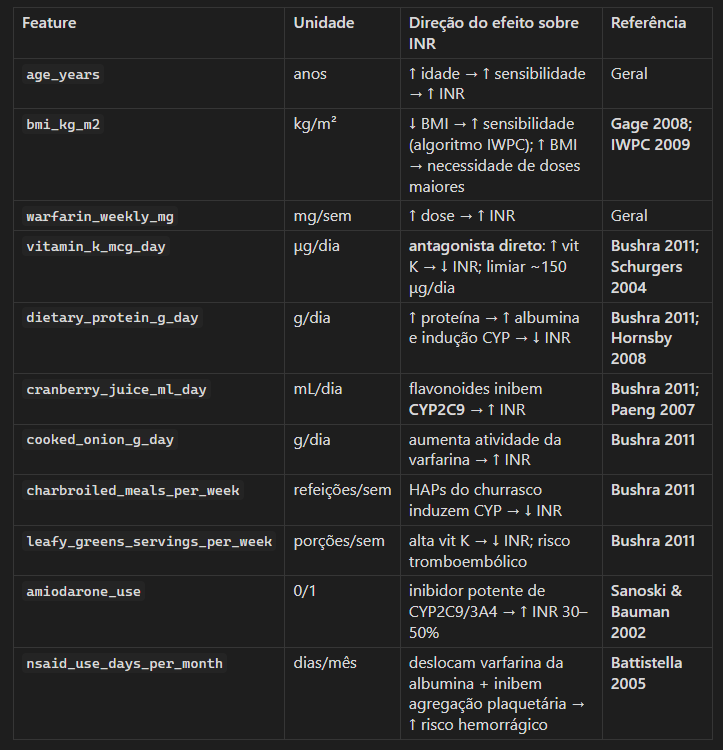

Resumo da literatura de como as features influenciam no INR

# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
# importando bibliotecas necessárias
import sys
import random #aleatórios
import warnings #omitir warnings
import missingno as ms # para tratamento de missings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns #prefiro o seaborn para visualização de gráficos, o matplotlib servirá como apoio quando necessário
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, GridSearchCV, StratifiedKFold #otimização de hiperparâmetros
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline #encadear pré+processamento e modelo sem data leakage
from sklearn.preprocessing import StandardScaler #preprocessamento
from sklearn.dummy import DummyClassifier #modelo ingênuo
from sklearn.linear_model import LogisticRegression #logistic regression pode me servir para comparação linear
from sklearn.tree import DecisionTreeClassifier #árvore simples
from xgboost import XGBClassifier #XGboost
from sklearn.ensemble import RandomForestClassifier #RandomForest
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, recall_score, precision_score,confusion_matrix,
    ConfusionMatrixDisplay
) #mantendo apenas métricas relacionadas a problemas de classificação supervisionada, adicionados o recall e precisão pois serão importantes
import time #monitorar tempos de execução

warnings.filterwarnings("ignore") #omitir warnings

#setando o estilo dos gráficos
sns.set_theme(
    style="whitegrid", #estilo mais clean
    palette="colorblind", #inclusão de pessoas com daltonismo com bom contraste
    context="notebook"  #estilo de fontes
)

SEED = 42 #semente para garantir reprodutibilidade do código
np.random.seed(SEED)
random.seed(SEED)

_inicio_notebook = time.perf_counter() #ajudar na contagem do tempo de execução do notebook

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


# 3. Seleção e carga de dados

## 3.1 Fonte dos dados

Como mencionado no tópico 1, o dataset foi gerado artificialmente com apoio de LLM. No entanto, foram utilizados artigos internacionais para geração dos dados. Foi gerado artificialmente pois não posso utilizar a amostra de dados orgânica da pesquisa científica da minha noiva.

Referência principal:

> Bushra, Aslam & Khan (2011). **"Food-Drug Interactions"**. *Oman Medical Journal*. Disponível em https://pmc.ncbi.nlm.nih.gov/articles/PMC3191675/

Outras referências:

Hornsby LB, Hester EK, Donaldson AR. Potential interaction between warfarin and high dietary protein intake. *Pharmacotherapy* 2008;28(4):536–9.

Paeng CH, Sprague M, Jackevicius CA. Interaction between warfarin and cranberry juice. *Clin Ther* 2007;29(8):1730–5.

Schurgers LJ et al. Effect of vitamin K intake on the stability of oral anticoagulant treatment. *Blood* 2004;104(9):2682–9.

Gage BF et al. Use of pharmacogenetic and clinical factors to predict the therapeutic dose of warfarin. *Clin Pharmacol Ther* 2008;84(3):326–31.

International Warfarin Pharmacogenetics Consortium. Estimation of the warfarin dose with clinical and pharmacogenetic data. *N Engl J Med* 2009;360(8):753–64.

Sanoski CA, Bauman JL. Clinical observations with the amiodarone/warfarin interaction. *Chest* 2002;121(1):19–23.

Battistella M et al. Risk of upper gastrointestinal hemorrhage in warfarin users concurrently using NSAIDs. *Arch Intern Med* 2005;165(2):189–92.

O dataset está hospedado no GitHub em Raw, no mesmo ambiente que está este notebook. Será carregado via URL.

In [2]:
#carga dos dados
url = "https://raw.githubusercontent.com/eng-jvamaral/MVPs-PosGrad-PUCRJ/refs/heads/main/PUCRJ-MVP-ML-VARF/warfarin_inr.csv" #puxando csv bruto (raw) do git

df = pd.read_csv(url)
df_raw = df.copy() #salvando o dataframe numa base de cópia para recuperar futuramente, caso necessário
df.tail()


,age_years,bmi_kg_m2,warfarin_weekly_mg,vitamin_k_mcg_day,dietary_protein_g_day,cranberry_juice_ml_day,cooked_onion_g_day,charbroiled_meals_per_week,leafy_greens_servings_per_week,amiodarone_use,nsaid_use_days_per_month,blood_type,region_code,inr_status
10842,74.6,33.5,36.6,138.0,59.4,18.7,32.9,4,7,0,3,A,SE,therapeutic
10843,85.5,33.7,21.1,89.0,83.1,9.6,42.2,1,9,0,7,B,S,therapeutic
10844,75.4,28.3,40.2,135.1,97.8,68.4,45.4,2,3,0,1,O,NE,therapeutic
10845,70.9,36.3,44.1,107.5,37.7,0.0,11.8,1,3,0,1,O,S,therapeutic
10846,53.3,23.9,51.4,120.5,52.6,103.3,7.6,1,1,0,3,A,NE,supratherapeutic


In [3]:
#estatística descritiva básica
df.describe()

,age_years,bmi_kg_m2,warfarin_weekly_mg,vitamin_k_mcg_day,dietary_protein_g_day,cranberry_juice_ml_day,cooked_onion_g_day,charbroiled_meals_per_week,leafy_greens_servings_per_week,amiodarone_use,nsaid_use_days_per_month
count,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.00000,10847.000000,10847.000000,10847.000000
mean,61.961326,27.054946,35.062718,111.152309,75.045367,55.081055,27.324680,1.60118,3.367014,0.126855,3.571771
std,14.927470,5.448554,10.610962,55.866347,22.612290,50.826590,23.075894,1.26750,2.152835,0.332826,2.012360
min,20.000000,16.000000,10.000000,10.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,51.700000,23.200000,27.900000,70.700000,59.600000,17.300000,10.900000,1.00000,2.000000,0.000000,2.000000
50%,62.200000,27.000000,35.000000,110.300000,74.500000,43.100000,22.000000,1.00000,3.000000,0.000000,3.000000
75%,72.300000,30.800000,42.200000,149.500000,90.700000,79.750000,37.800000,2.00000,5.000000,0.000000,5.000000
max,95.000000,45.000000,75.900000,329.900000,151.000000,364.500000,195.900000,9.00000,14.000000,1.000000,17.000000


## 3.2 Dicionário de Dados

> **Cobertura:** todas as 14 colunas (11 numéricas relevantes + 2 categóricas + 1 target).
> **Total de registros:** 10.847 pacientes sintéticos.
> **Período de referência:** consumo dietético dos últimos 7 dias antes da medição do INR; uso de medicamentos no mês anterior.

---

### Variáveis demográficas e antropométricas

**1. `age_years`**
- Tipo: numérica contínua · Unidade: anos · Faixa: 20,0 – 95,0
- Idade do paciente no momento da medição do INR.

**2. `bmi_kg_m2`**
- Tipo: numérica contínua · Unidade: kg/m² · Faixa: 16,0 – 45,0
- Índice de Massa Corporal (peso ÷ altura²). Indicador de composição corporal usado no algoritmo IWPC de dose.

---

### Variável de tratamento

**3. `warfarin_weekly_mg`**
- Tipo: numérica contínua · Unidade: mg/semana · Faixa: 10,0 – 80,0
- Dose semanal total de varfarina prescrita ao paciente. Doses usuais de manutenção variam entre 14 e 70 mg/semana.

---

### Variáveis dietéticas

**4. `vitamin_k_mcg_day`**
- Tipo: numérica contínua · Unidade: μg/dia · Faixa: 10,0 – 400,0
- Ingestão diária estimada de vitamina K, somando fontes alimentares e suplementos. Recomendação adulta: ~90 μg/dia (mulheres) e ~120 μg/dia (homens).

**5. `dietary_protein_g_day`**
- Tipo: numérica contínua · Unidade: g/dia · Faixa: 25,0 – 180,0
- Ingestão diária estimada de proteína (carnes, ovos, laticínios, leguminosas).

**6. `cranberry_juice_ml_day`**
- Tipo: numérica contínua · Unidade: mL/dia · Faixa: 0,0 – 400,0
- Volume diário de suco de cranberry consumido.

**7. `cooked_onion_g_day`**
- Tipo: numérica contínua · Unidade: g/dia · Faixa: 0,0 – 200,0
- Quantidade diária de cebola cozida consumida (refogados, sopas, ensopados).

**8. `charbroiled_meals_per_week`**
- Tipo: numérica discreta · Unidade: refeições/semana · Faixa: 0 – 10
- Número de refeições por semana incluindo alimentos grelhados em carvão ou defumados (churrasco, hambúrguer grelhado).

**9. `leafy_greens_servings_per_week`**
- Tipo: numérica discreta · Unidade: porções/semana · Faixa: 0 – 20
- Porções semanais de hortaliças folhosas verde-escuras (couve, espinafre, brócolis, rúcula). Uma porção ≈ 1 xícara crua ou ½ xícara cozida.

---

### Variáveis de medicação concomitante

**10. `amiodarone_use`**
- Tipo: binária · Valores: {0, 1}
- Indicador de uso concomitante de amiodarona (antiarrítmico). `1` = paciente em uso; `0` = não usa.

**11. `nsaid_use_days_per_month`**
- Tipo: numérica discreta · Unidade: dias/mês · Faixa: 0 – 30
- Número de dias no último mês com uso de anti-inflamatório não-esteroidal (ibuprofeno, naproxeno, diclofenaco, AAS em dose anti-inflamatória), também chamado de AINE (anti-inflamatório não-esteroidal).

---

### Variáveis gerais

**12. `blood_type`**
- Tipo: categórica nominal · Valores: A, B, AB, O
- Tipo sanguíneo do sistema ABO. Sem relação com o metabolismo da varfarina ou com a síntese de fatores de coagulação vitamina K-dependentes.

**13. `region_code`**
- Tipo: categórica nominal · Valores: N, NE, CO, SE, S
- Região do Brasil onde o paciente reside (Norte, Nordeste, Centro-Oeste, Sudeste, Sul). Sem efeito causal direto sobre o INR.

---

### Variável-alvo (target)

**14. `inr_status`**
- Tipo: categórica binária · Valores: `therapeutic`, `supratherapeutic`
- Status do INR na medição:
  - `therapeutic` = INR ≤ 3,0 (dentro ou abaixo da faixa-alvo)
  - `supratherapeutic` = INR > 3,0 (acima da faixa-alvo, risco hemorrágico aumentado)

---

### Observações gerais

- **Dados ausentes:** não há.
- **Codificação de texto:** UTF-8.
- **Separador:** vírgula.
- **Cabeçalho:** presente na primeira linha.

## 3.3 Visão geral do dataset

In [4]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (10847, 14)

Tipos de dados:


,tipo
age_years,float64
bmi_kg_m2,float64
warfarin_weekly_mg,float64
vitamin_k_mcg_day,float64
dietary_protein_g_day,float64
cranberry_juice_ml_day,float64
cooked_onion_g_day,float64
charbroiled_meals_per_week,int64
leafy_greens_servings_per_week,int64
amiodarone_use,int64


O dataset possui 10.847 linhas (pacientes), 14 colunas (features), sendo 11 numéricas e 3 categóricas, incluindo o target (inr_status).

<Axes: >

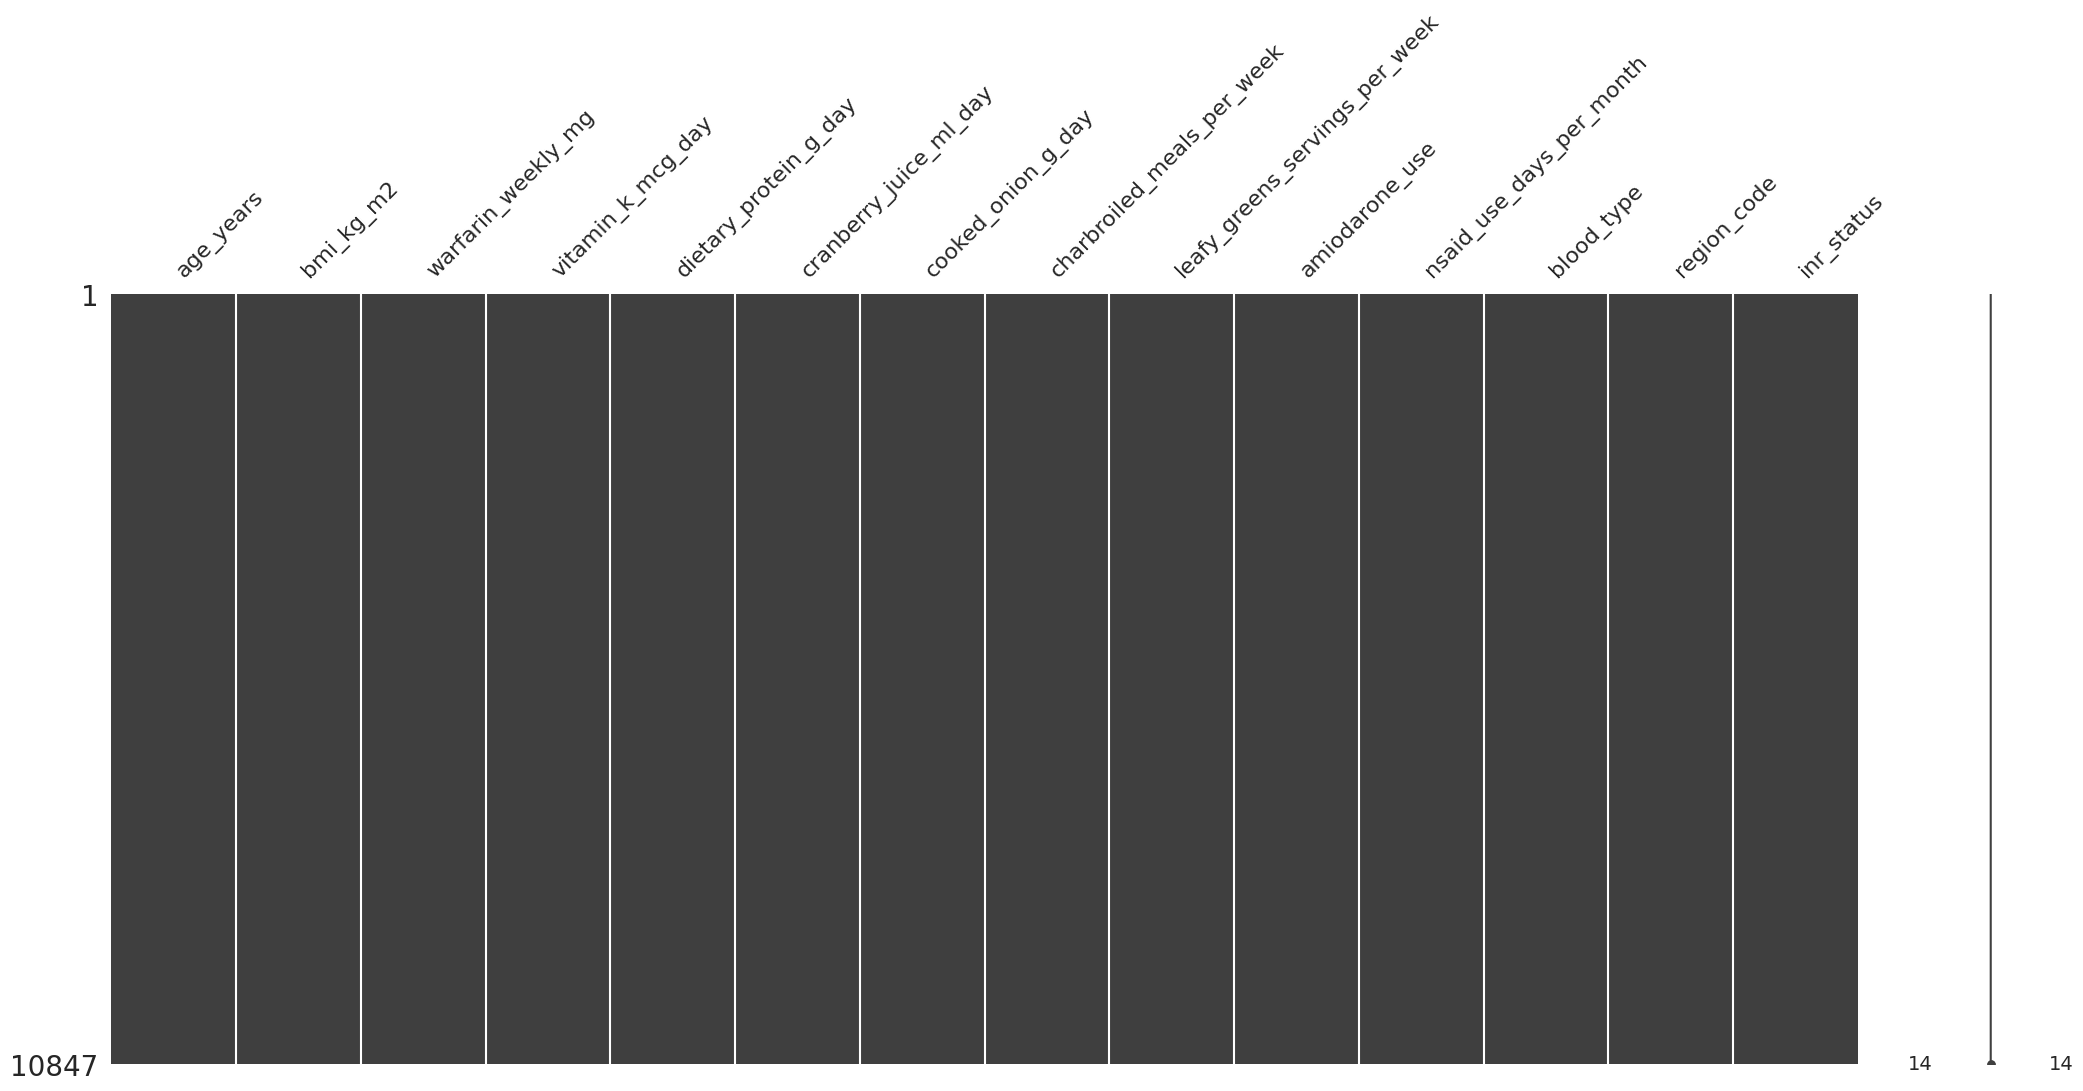

In [5]:
ms.matrix(df) #conferindo visualmente como os missings estão dispersos, o quanto o dado está 'picotado'

In [6]:
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


In [7]:
display(df.sample(5, random_state=SEED)) #sorteando amostras do dataset

,age_years,bmi_kg_m2,warfarin_weekly_mg,vitamin_k_mcg_day,dietary_protein_g_day,cranberry_juice_ml_day,cooked_onion_g_day,charbroiled_meals_per_week,leafy_greens_servings_per_week,amiodarone_use,nsaid_use_days_per_month,blood_type,region_code,inr_status
4704,72.4,32.1,52.1,137.4,84.9,85.5,15.9,0,3,0,3,O,SE,therapeutic
7735,57.4,23.2,47.0,10.0,87.4,56.6,11.5,3,0,1,5,O,SE,supratherapeutic
6903,34.0,31.8,31.5,183.1,73.1,0.0,0.0,2,4,0,2,A,NE,supratherapeutic
7850,67.8,22.8,25.3,108.3,68.2,62.1,50.0,2,2,0,9,O,SE,therapeutic
360,59.5,27.5,31.0,126.2,99.7,56.2,21.5,0,5,0,6,O,SE,therapeutic


O dataset está completamente preenchido, sem instâncias vazias. Na vida real é provável que um paciente X tenha o dado de um exame específico e o Y não, mas para o objeto de estudo, vou seguir com o dataset assim pra me concentrar nas modelagens. Nesse caso dispensa tratamento de missings (drops ou imputers).

# 4. Análise exploratória dos dados

In [8]:
#estatística descritiva básica
df.describe()

,age_years,bmi_kg_m2,warfarin_weekly_mg,vitamin_k_mcg_day,dietary_protein_g_day,cranberry_juice_ml_day,cooked_onion_g_day,charbroiled_meals_per_week,leafy_greens_servings_per_week,amiodarone_use,nsaid_use_days_per_month
count,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.000000,10847.00000,10847.000000,10847.000000,10847.000000
mean,61.961326,27.054946,35.062718,111.152309,75.045367,55.081055,27.324680,1.60118,3.367014,0.126855,3.571771
std,14.927470,5.448554,10.610962,55.866347,22.612290,50.826590,23.075894,1.26750,2.152835,0.332826,2.012360
min,20.000000,16.000000,10.000000,10.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,51.700000,23.200000,27.900000,70.700000,59.600000,17.300000,10.900000,1.00000,2.000000,0.000000,2.000000
50%,62.200000,27.000000,35.000000,110.300000,74.500000,43.100000,22.000000,1.00000,3.000000,0.000000,3.000000
75%,72.300000,30.800000,42.200000,149.500000,90.700000,79.750000,37.800000,2.00000,5.000000,0.000000,5.000000
max,95.000000,45.000000,75.900000,329.900000,151.000000,364.500000,195.900000,9.00000,14.000000,1.000000,17.000000


Destaque para o uso de amiodarona: apenas 12% da amostra faz uso do medicamento (antiarrítmico).

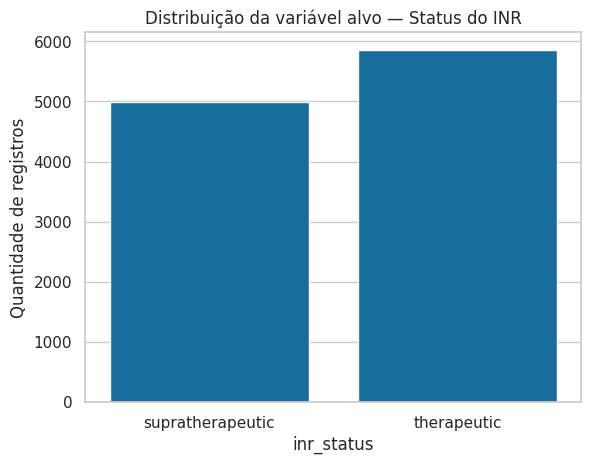

In [9]:
#avaliando o desbalanceamento do target
sns.countplot(data=df,x='inr_status')
plt.title('Distribuição da variável alvo — Status do INR')
plt.ylabel('Quantidade de registros')
display()

In [10]:
#registrando a prevalência do pior caso do target para efeito de comparação
prev_base = (df["inr_status"] == "supratherapeutic").mean()
print(f"Prevalência base de supratherapeutic: {prev_base:.1%}")

Prevalência base de supratherapeutic: 46.0%


Os dados target estão suficientemente equilibrados, na minha avaliação a pequena diferença dispensa o tratamento rigoroso de balanceamento para treinamento do modelo.

## H1 - Idoso magro tem ≥ 2× a prevalência média?

In [11]:
mask_h1 = (df["age_years"] > 70) & (df["bmi_kg_m2"] < 23) #separaçao das caracteristicas (mascara) agrupando pelas condições
prev_h1 = (df.loc[mask_h1, "inr_status"] == "supratherapeutic").mean() #separando quais dos grupos são supra
n_h1 = mask_h1.sum()

print(f"Idoso magro (idade>70 e BMI<23): n={n_h1} ({n_h1/len(df):.1%} da amostra)")
print(f"Prevalência supratherapeutic neste grupo: {prev_h1:.1%}")
print(f"Razão vs. base: {prev_h1/prev_base:.2f}x")
print(f"H1 confirmada? {'SIM' if prev_h1/prev_base >= 2 else 'NÃO'}")

Idoso magro (idade>70 e BMI<23): n=1008 (9.3% da amostra)
Prevalência supratherapeutic neste grupo: 93.8%
Razão vs. base: 2.04x
H1 confirmada? SIM


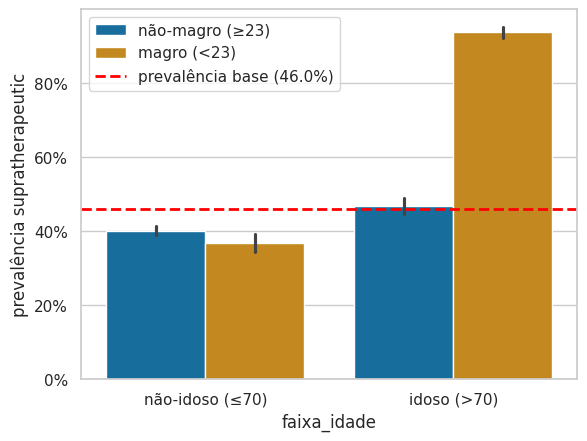

In [12]:
from matplotlib.ticker import PercentFormatter

df_h1 = df.copy()  # cópia do df original

# categoriza pacientes por idade
df_h1["faixa_idade"] = np.where(df_h1["age_years"] > 70, "idoso (>70)", "não-idoso (≤70)")

# categoriza pacientes pelo IMC (BMI)
df_h1["faixa_bmi"]   = np.where(df_h1["bmi_kg_m2"] < 23, "magro (<23)", "não-magro (≥23)")

# cria variável binária indicando se é supra (1), para calcular proporção pela média
df_h1["is_supra"]    = (df_h1["inr_status"] == "supratherapeutic").astype(int)

# prevalência base (média geral da população)
prev_base = df_h1["is_supra"].mean()

# --- barplot ---
ax = sns.barplot(
    data=df_h1,
    x="faixa_idade",
    y="is_supra",
    hue="faixa_bmi",
)

# linha vermelha de prevalência base
ax.axhline(prev_base, color="red", linestyle="--", linewidth=2,
           label=f"prevalência base ({prev_base:.1%})")

# formata eixo y como %
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("prevalência supratherapeutic")

ax.legend()
plt.show()

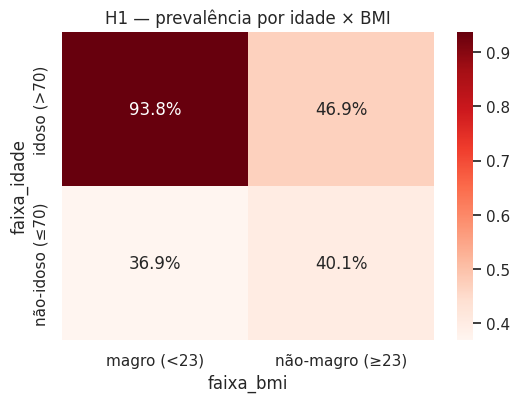

In [13]:
tab = df_h1.groupby(["faixa_idade", "faixa_bmi"])["is_supra"].mean().unstack()
plt.figure(figsize=(6,4))
sns.heatmap(tab, annot=True, fmt=".1%", cmap="Reds")
plt.title("H1 — prevalência por idade × BMI")
plt.show()

O quadrante "idoso magro" (idade > 70 e IMC < 23) apresenta prevalência de INR supraterapêutico aproximadamente 2× superior à linha base da população, **confirmando H1**. Os demais três quadrantes oscilam ao redor da prevalência base, indicando que a elevação de risco depende da combinação simultânea dos dois fatores. Esse padrão é consistente com o perfil de hipersensibilidade descrito na literatura geriátrica, decorrente de menor volume de distribuição associado a função hepática reduzida.

### H2 -  A relação entre ingestão de vitamina K e INR supraterapêutico não é linear: há um patamar abaixo do qual o risco cresce de forma abrupta.

In [14]:
from matplotlib.ticker import PercentFormatter

df_h2 = df.copy()
df_h2["is_supra"] = (df_h2["inr_status"] == "supratherapeutic").astype(int)

# divide vitamina K em quintis ordenados do menor para o maior
df_h2["vk_quintil"] = pd.qcut(
    df_h2["vitamin_k_mcg_day"],
    q=5,
    labels=["Q1 (mais baixo)", "Q2", "Q3", "Q4", "Q5 (mais alto)"]
)

# prevalência base
prev_base = df_h2["is_supra"].mean()

# prevalência de supraterapêutico em cada quintil
prev_por_quintil = df_h2.groupby("vk_quintil", observed=True)["is_supra"].mean()

# faixas de valor cobertas por cada quintil (para referência clínica)
faixas = df_h2.groupby("vk_quintil", observed=True)["vitamin_k_mcg_day"].agg(["min", "max"]).round(1)

print("Prevalência de supraterapêutico por quintil de vitamina K:")
print(prev_por_quintil.apply(lambda x: f"{x:.1%}"))
print("\nFaixas de vitamina K (μg/dia) em cada quintil:")
print(faixas)

queda_inicial = (prev_por_quintil.iloc[0] - prev_por_quintil.iloc[1]) * 100  # Q1 -> Q2
queda_final   = (prev_por_quintil.iloc[3] - prev_por_quintil.iloc[4]) * 100  # Q4 -> Q5

print(f"\nQueda Q1 -> Q2: {queda_inicial:.1f} pp")
print(f"Queda Q4 -> Q5: {queda_final:.1f} pp")

Prevalência de supraterapêutico por quintil de vitamina K:
vk_quintil
Q1 (mais baixo)    64.0%
Q2                 47.8%
Q3                 36.6%
Q4                 38.7%
Q5 (mais alto)     42.9%
Name: is_supra, dtype: object

Faixas de vitamina K (μg/dia) em cada quintil:
                   min    max
vk_quintil                   
Q1 (mais baixo)   10.0   61.0
Q2                61.1   95.9
Q3                96.0  125.1
Q4               125.2  159.3
Q5 (mais alto)   159.4  329.9

Queda Q1 -> Q2: 16.1 pp
Queda Q4 -> Q5: -4.2 pp


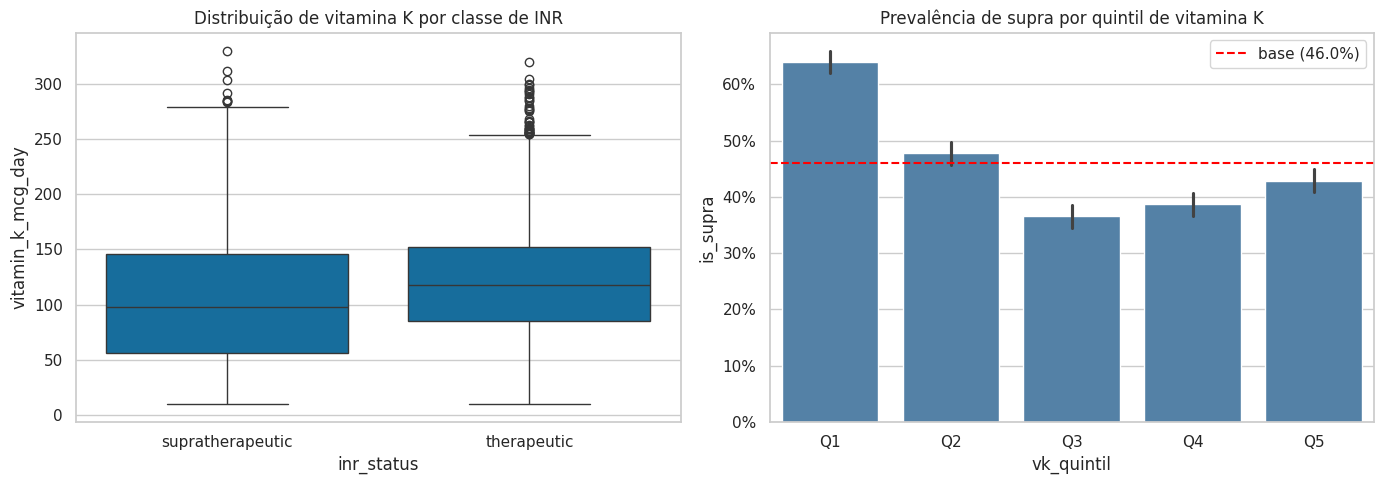

In [15]:
df_h2 = df.copy()

#discretização para 0 (terapuetico) e 1 (supraterapeutico) do target
df_h2["is_supra"]   = (df_h2["inr_status"] == "supratherapeutic").astype(int)

#divido as ocorrências de consumo de vitamin K em quintis (separação a cada 20% dos dados aproximadamente)
#como são ordenados crescentemente, Q1 é o grupo com menor consumo de vitamin K e Q5 o maior.
df_h2["vk_quintil"] = pd.qcut(df_h2["vitamin_k_mcg_day"], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])


prev_base = df_h2["is_supra"].mean() #calculo a proporção do target


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#primeiro grafico um boxplot simples entre os targets
sns.boxplot(data=df_h2, x="inr_status", y="vitamin_k_mcg_day", ax=axes[0])
axes[0].set_title("Distribuição de vitamina K por classe de INR")

#segundo grafico são os quintis
sns.barplot(data=df_h2, x="vk_quintil", y="is_supra", ax=axes[1], color="steelblue")
axes[1].axhline(prev_base, color="red", linestyle="--", label=f"base ({prev_base:.1%})")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Prevalência de supra por quintil de vitamina K")
axes[1].legend()

plt.tight_layout()
plt.show()

Os indivíduos pertencentes ao quintil de menor consumo de vitamina K (Q1, faixa <70 μg/dia) apresentam prevalência de INR supraterapêutico de aproximadamente 64%, bem acima da prevalência base da amostra (46%). Já no segundo quintil a prevalência cai abruptamente para cerca de 47%, e os quintis Q3 a Q4 estabilizam entre 36% e 38%.

Esse padrão de queda acentuada do Q1 para o Q2 seguida de estabilização nos quintis superiores caracteriza o efeito de patamar previsto em **H2**: abaixo de aproximadamente 70 μg/dia a vitamina K dietética torna-se insuficiente para neutralizar a varfarina, e o INR escapa para cima de forma consistente. Acima desse limiar, incrementos adicionais de vitamina K oferecem pouco benefício marginal sobre o controle do INR, mas há uma tendência de crescimento que chama um alerta. Aumento excessivo de vitamina K também é nocivo e diminui o efeito da varfarina, promovendo risco de tromboses, embolias etc.

O boxplot complementa essa leitura: a distribuição de vitamina K nos pacientes supraterapêuticos tem mediana visivelmente menor que nos terapêuticos, com cauda inferior mais densa. H2 Confirmada!

## Verificação geral das features

### Histogramas principais

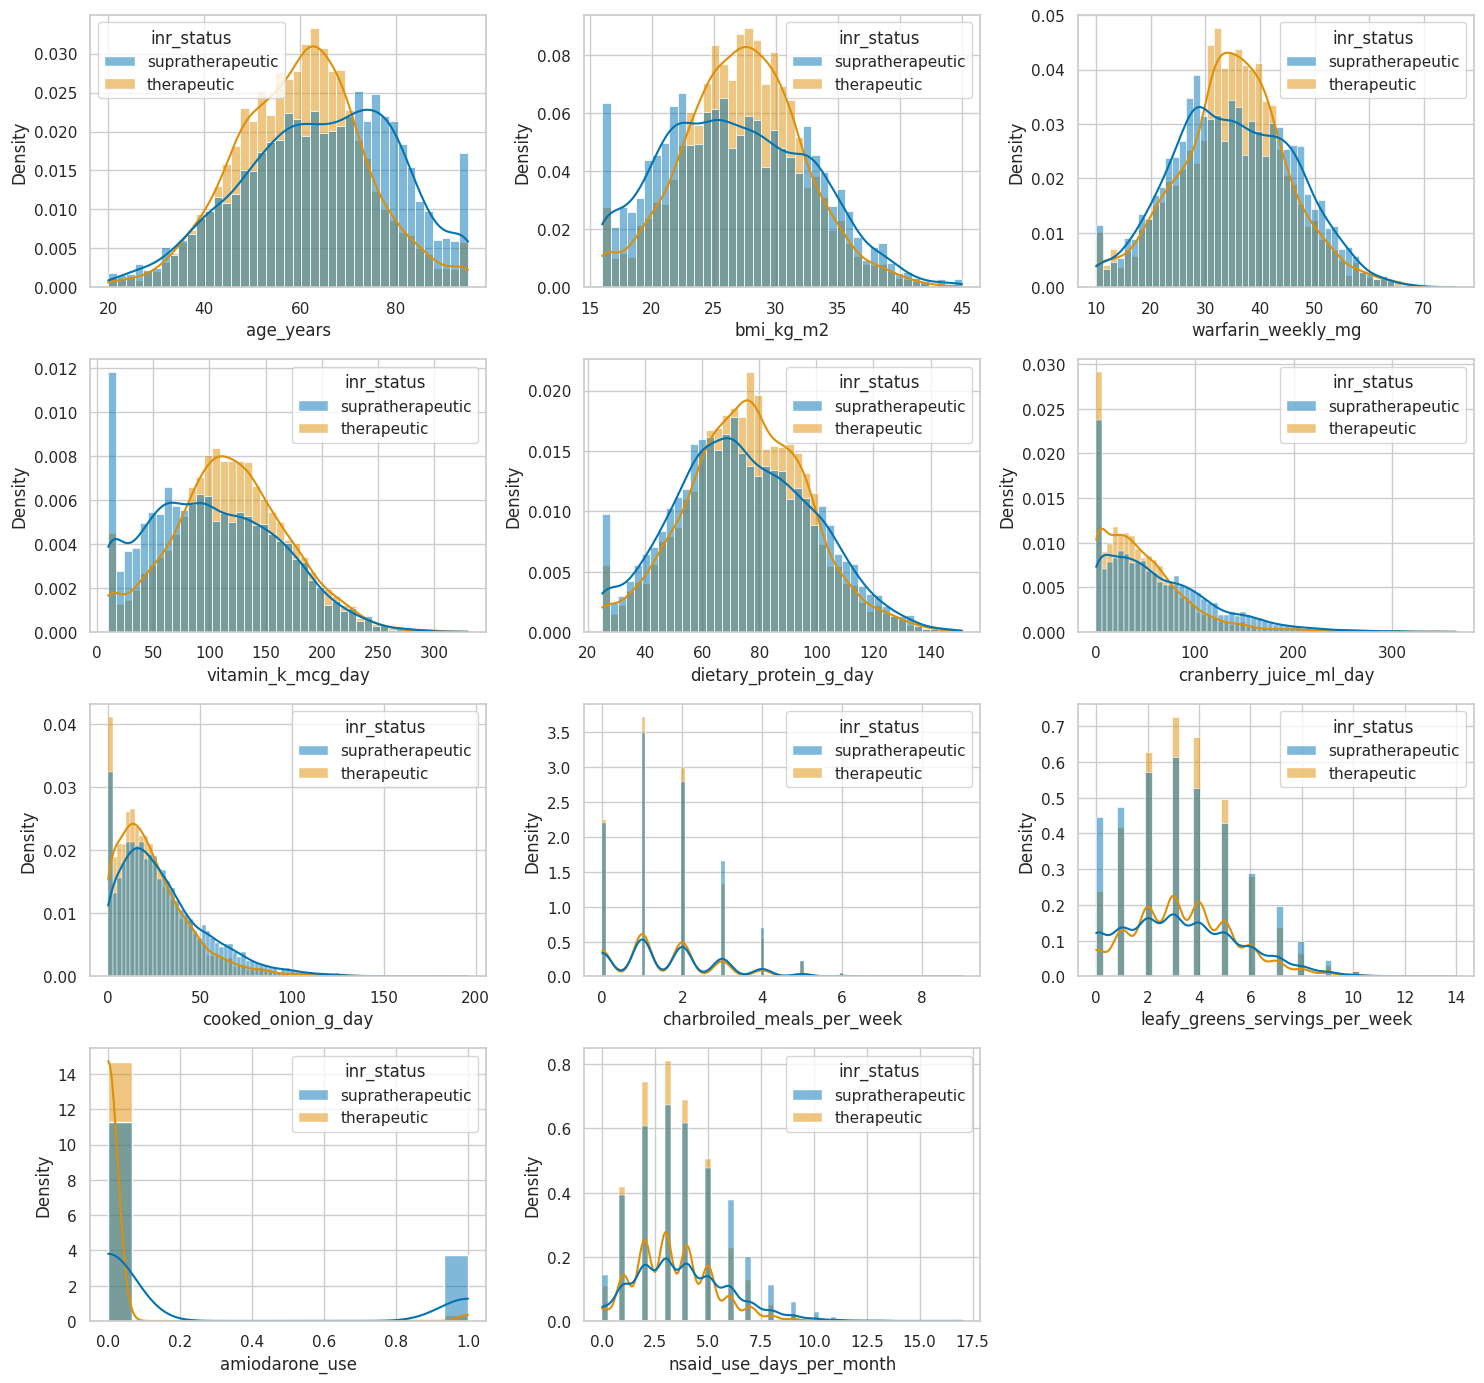

In [16]:
features_num = [
    "age_years", "bmi_kg_m2", "warfarin_weekly_mg",
    "vitamin_k_mcg_day", "dietary_protein_g_day", "cranberry_juice_ml_day",
    "cooked_onion_g_day", "charbroiled_meals_per_week",
    "leafy_greens_servings_per_week", "amiodarone_use", "nsaid_use_days_per_month"
] #separando as feat numericas

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten() #achatando array para 1D.

for i, col in enumerate(features_num):
    sns.histplot(
        data=df,
        x=col,
        hue="inr_status",
        kde=True,
        stat="density",
        common_norm=False,
        palette="colorblind",
        ax=axes[i]
    )

# remove o subplot vazio (são 11 features em grade 4x3)
axes[-1].axis("off")

plt.tight_layout()
plt.show()

As variáveis apresentam escalas heterogêneas, variando de atributos binários (amiodarona) a variáveis contínuas com ampla faixa de valores (vitamina K), o que justifica a padronização para modelos sensíveis à escala, como Regressão Logística e Árvores Simples. Observam-se distribuições assimétricas à direita para vitamina K, suco de cranberry, cebola cozida e uso de AINE, sugerindo possível benefício de transformação logarítmica (log1p) seguida de padronização.

Idade, IMC, dose semanal de varfarina e ingestão de proteínas apresentam distribuições mais próximas da normalidade e admitem padronização direta. Embora exista deslocamento entre as distribuições dos grupos terapêutico e supraterapêutico, especialmente para idade e vitamina K, a sobreposição entre as classes é considerável. Esse deslocamento, inclusive, pode ser benéfico para o modelo encontrar fronteiras para tomar decisão.

Esse padrão é coerente com a premissa P3 e indica que a predição do INR dependerá da combinação de múltiplas variáveis em vez de um único fator isolado, justificando a opção por modelos capazes de capturar interações não-lineares.


### Correlações

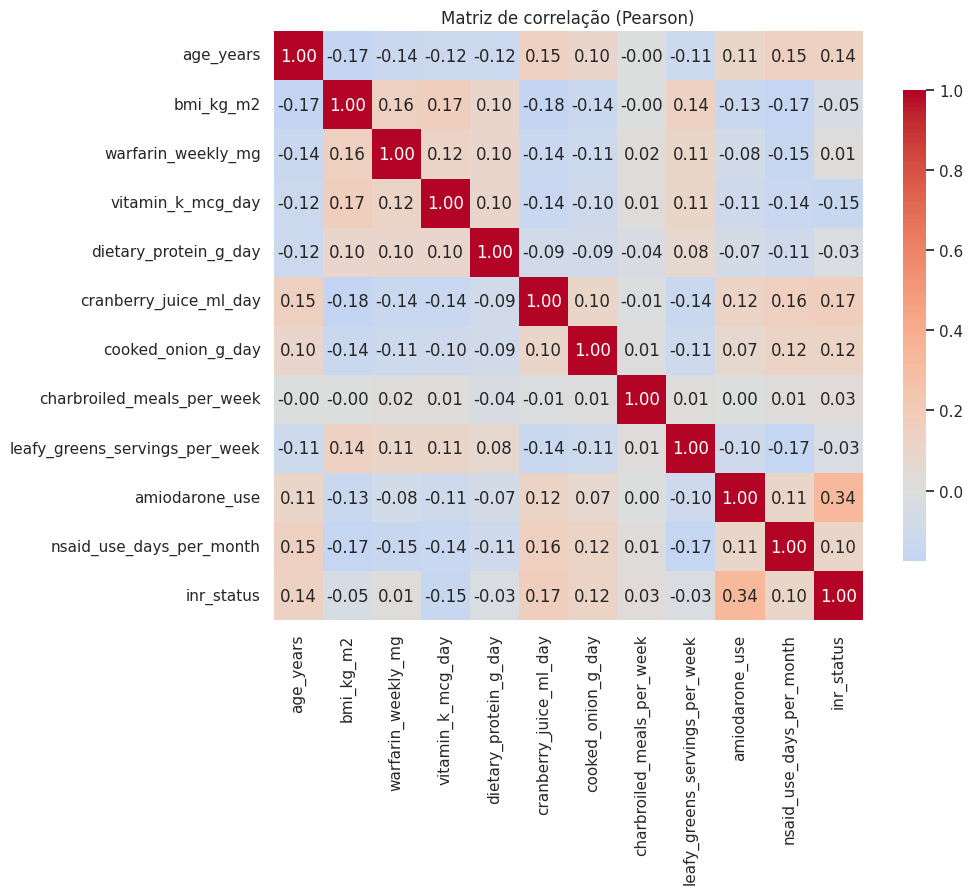

In [17]:
df_corr = df.drop(columns=["blood_type", "region_code"]).copy()
df_corr["inr_status"] = (df_corr["inr_status"] == "supratherapeutic").astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.tight_layout()
plt.show()

A correlação não traz nenhum dado valioso para feature isolada, nesse caso, apenas para amiodarona que já era esperado. Vamos avaliar os boxplots para avaliar as features isoladas com mais qualidade.

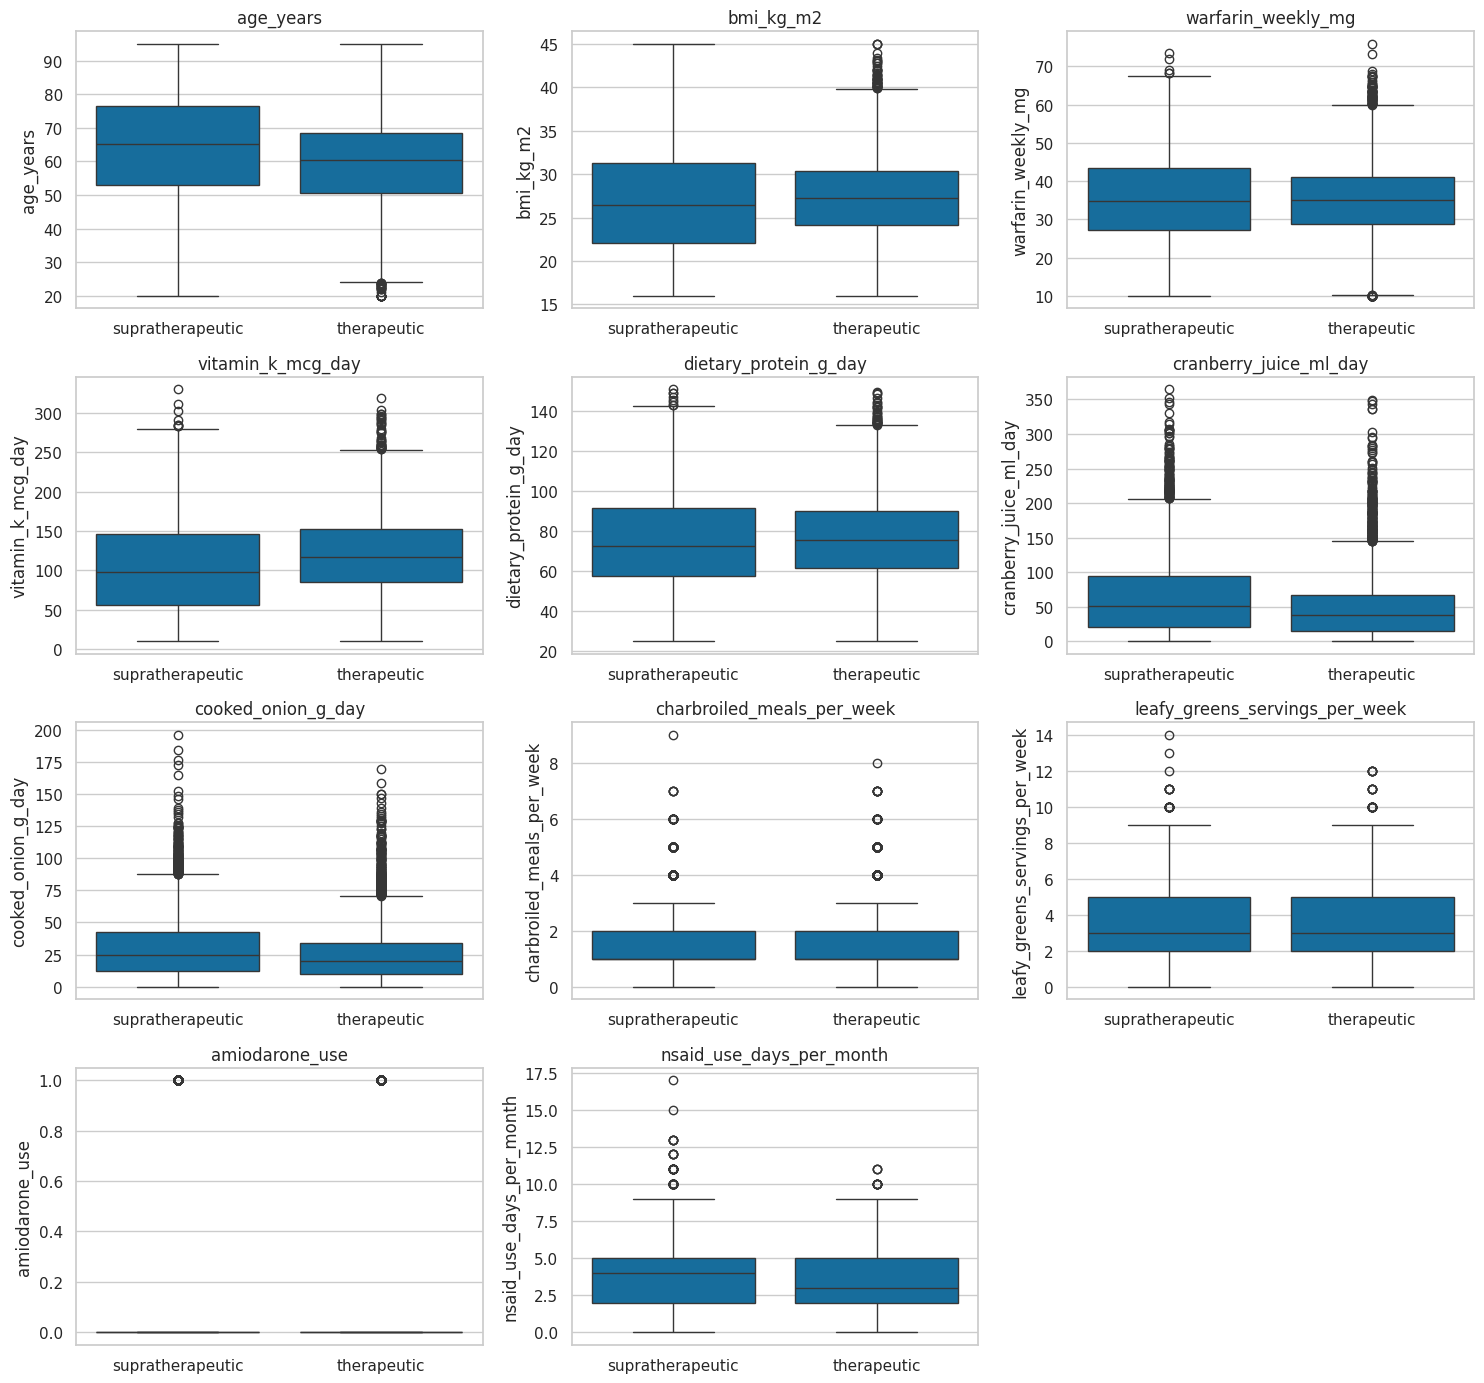

In [18]:
features_num = [
    "age_years", "bmi_kg_m2", "warfarin_weekly_mg",
    "vitamin_k_mcg_day", "dietary_protein_g_day", "cranberry_juice_ml_day",
    "cooked_onion_g_day", "charbroiled_meals_per_week",
    "leafy_greens_servings_per_week", "amiodarone_use", "nsaid_use_days_per_month"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(features_num):
    sns.boxplot(data=df, x="inr_status", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

A análise dos boxplots por classe confirma que nenhuma feature isolada permite
discriminar pacientes terapêuticos de supraterapêuticos com clareza. Apesar de
pequenos deslocamentos de mediana em variáveis como idade, vitamina K e suco de
cranberry, a sobreposição das distribuições entre os dois grupos é substancial em
todas as features avaliadas.

Esse resultado é consistente com a premissa P3 e com o que se espera clinicamente:
o INR supraterapêutico emerge da combinação simultânea de múltiplos fatores de
risco em um mesmo paciente, e não de qualquer variável dominante isolada. A análise
exploratória, portanto, atinge seu limite analítico aqui PARA ESTE MVP. A próxima etapa vou trabalhar nos
modelos capazes de capturar interações multivariadas para responder às hipóteses
H3 e H4.

# 5. Preparação dos dados e divisão treino/teste

Antes de iniciar, existem features que não tem respaldo farmacológico até o momento com relação às interações da varfarina, que é o tipo sanguíneo e a região em que o paciente mora.

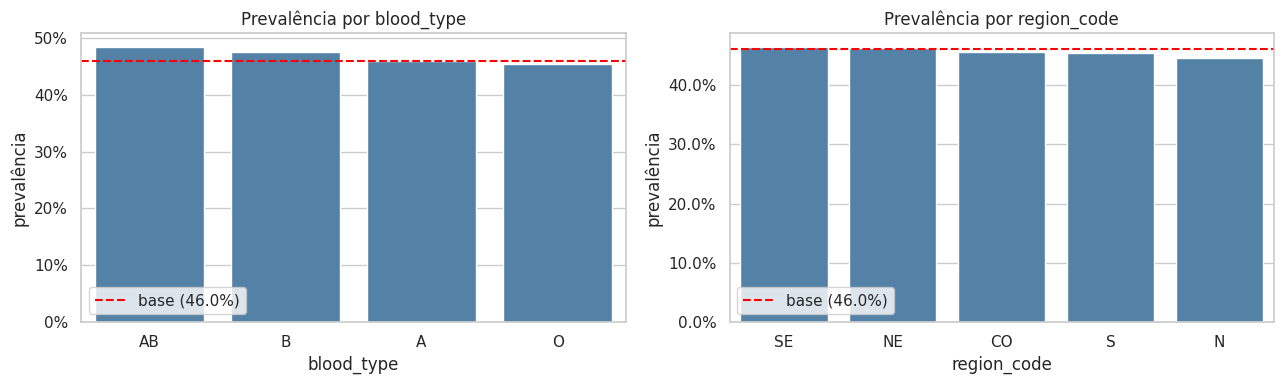

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
prev_base = (df["inr_status"] == "supratherapeutic").mean()

for ax, col in zip(axes, ["blood_type", "region_code"]):
    prev = df.groupby(col)["inr_status"].apply(
        lambda x: (x == "supratherapeutic").mean()
    ).sort_values(ascending=False)

    sns.barplot(x=prev.index, y=prev.values, ax=ax, color="steelblue")
    ax.axhline(prev_base, ls="--", c="red", label=f"base ({prev_base:.1%})")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=f"Prevalência por {col}", xlabel=col, ylabel="prevalência")
    ax.legend()

plt.tight_layout()
plt.show()

A análise da prevalência de INR supraterapêutico em cada categoria confirma a expectativa teórica: as proporções permanecem estatisticamente equivalentes à prevalência base em todos os grupos.

Portanto, as duas features são removidas do conjunto de modelagem. Mantê-las representaria risco de overfitting a padrões espúrios e introduziria vieses indesejáveis em hipotético uso clínico do modelo.

In [20]:
df_model = df.drop(columns=["blood_type", "region_code"]) #drop das variáveis irrelevantes para o modelo


X = df_model.drop(columns=["inr_status"]) #separação das features X
y = (df_model["inr_status"] == "supratherapeutic").astype(int) #One-Hot Enconding sutil aqui, discretizando o target para binário

print(f"Features (X): {X.shape[1]} colunas, {X.shape[0]} linhas")
print(f"Target (y):   {y.shape[0]} linhas")
print(f"Distribuição do target:")
print(y.value_counts(normalize=True).round(3)) #apenas para conferência, proporção já vista antes

Features (X): 11 colunas, 10847 linhas
Target (y):   10847 linhas
Distribuição do target:
inr_status
0    0.54
1    0.46
Name: proportion, dtype: float64


Vou adotar divisão clássica 75/25 com estratificação pela target. A estratificação garante que a proporção 54/46 observada na população completa seja preservada nos dois conjuntos, condição necessária para que as métricas de avaliação reflitam o desempenho esperado em uma população real e não sejam contaminadas por desbalanceamento artificial.

O parâmetro random_state=SEED é fixado em todas as operações estocásticas do projeto (split, modelos, validação cruzada), atendendo ao critério de reprodutibilidade.

O conjunto de teste fica reservado e intocado até a avaliação final. Toda a exploração de modelos, ajuste de hiperparâmetros e seleção do candidato final é feita exclusivamente sobre o conjunto de treino, com validação cruzada, com o objetivo de prevenir o vazamento de informação e garantir que a métrica reportada no fim represente honestamente o desempenho do modelo em dados nunca vistos.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=SEED
)

print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} positivos)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} positivos)")

Treino: 8135 amostras (46.0% positivos)
Teste:  2712 amostras (46.0% positivos)


Ciente que em outros trabalhos, a divisão pode não ser tão perfeita assim.

Já para a comparação entre modelos candidatos e o ajuste de hiperparâmetros (etapas 7, 8 e 9), vou aplicar validação cruzada estratificada com 5 folds. A estratificação dentro de cada fold preserva a proporção das classes, e os 5 folds oferecem um bom equilíbrio entre custo computacional e estabilidade da estimativa.

Essa estratégia atende diretamente ao critério C4: o desvio-padrão do F1-score entre os folds funciona como medida de robustez do modelo. Variação inferior a 2 pontos percentuais entre folds indica que o modelo é estável e que a métrica reportada não é fruto de uma divisão favorável dos dados.

A validação cruzada opera apenas sobre o conjunto de treino. O conjunto de teste permanece reservado até a avaliação final do modelo escolhido.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Estratégia de CV: {cv}")

Estratégia de CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Nota importante: o holdout e o CV foram feitos dessa maneira pois os dados não possuem nenhuma regra temporal que inviabilize o shuffle ou cutoff aleatório. Em outras palavras, >quando< o dado foi coletado não interfere na predição.

# 6. Pipeline e pré-processamento

A revisão das etapas convencionais de pré-processamento, frente às características do dataset, indica que apenas a padronização das features numéricas é necessária:

- **Imputação:** dispensada. O dataset não possui valores ausentes.
- **Padronização:** necessária para modelos sensíveis à escala, conforme observado na análise das distribuições (Seção 4).
- **Encoding:** dispensado. As únicas variáveis categóricas (blood_type, region_code) foram descartadas na seleção de features (Seção 5).
- **Seleção de atributos:** já realizada com base em justificativa científica e validação empírica.
- **Engenharia de atributos:** descartada por opção metodológica. O projeto assume que as interações relevantes serão capturadas pelos modelos não-lineares, e não por features derivadas manualmente. Essa decisão também serve como teste das premissas: se o modelo atingir F1 ≥ 0,90 sem features derivadas, fica demonstrado que o sinal está acessível diretamente nas variáveis originais.


In [23]:
# lista de features numéricas (todas, após o descarte de blood_type e region_code)
features_numericas = X.columns.tolist()

# pré-processador para modelos sensíveis à escala
preprocessador_padronizado = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_numericas)
    ],
    remainder="drop"
)

# pré-processador identidade (apenas passagem direta) para árvores
preprocessador_passthrough = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_numericas)
    ],
    remainder="drop"
)

O pipeline é construído com ColumnTransformer e Pipeline do scikit-learn. Essa estrutura tem três vantagens:

1. **Encapsulamento:** o pré-processamento e o modelo viram um objeto único, evitando aplicação inconsistente das transformações entre treino e teste.
2. **Prevenção de vazamento:** o StandardScaler aprende os parâmetros (média e desvio) apenas no conjunto de treino e os aplica no conjunto de teste, sem contaminação.
3. **Reprodutibilidade:** o pipeline pode ser serializado, versionado e aplicado de forma idêntica em qualquer reexecução.

Foram definidas duas variantes do pipeline:

- **Pipeline com padronização** para modelos sensíveis à escala (Regressão Logística).
- **Pipeline sem padronização** para modelos invariantes à escala (Árvore de Decisão, Random Forest, XGBoost).

Manter pipelines distintos é mais limpo do que aplicar padronização desnecessária aos modelos baseados em árvores.

Aplicar StandardScaler em árvores não prejudica o desempenho, mas adiciona um passo computacional sem benefício e dificulta a interpretação dos splits.

Para evitar repetição de código nas próximas seções, é útil definir uma função que recebe um modelo e retorna o pipeline completo, escolhendo automaticamente o pré-processador adequado.

In [24]:
def criar_pipeline(modelo, padronizar=True):
    """
    Cria um pipeline scikit-learn com pré-processamento e modelo.

    Parâmetros:
        modelo: instância de classificador scikit-learn
        padronizar: se True, aplica StandardScaler; se False, bypassa as features cruas
    """
    preproc = preprocessador_padronizado if padronizar else preprocessador_passthrough #Se padronizar for True → preproc recebe preprocessador_padronizado
    return Pipeline([                                                                   #se padronizar for False → preproc recebe preprocessador_passthrough (que não transforma nada, só deixa os dados passarem direto)
        ("preproc", preproc),
        ("modelo",  modelo)
    ])

In [25]:
#rodando um treino de regressao logistica so para teste da função
pipe_teste = criar_pipeline(LogisticRegression(max_iter=2000, random_state=42), padronizar=True)
pipe_teste.fit(X_train, y_train)

print("Pipeline montado com sucesso.")
print(f"Acurácia (treino): {pipe_teste.score(X_train, y_train):.3f}")
print(f"Acurácia (teste):  {pipe_teste.score(X_test, y_test):.3f}")

# verifica que o StandardScaler foi ajustado nas features numéricas
scaler = pipe_teste.named_steps["preproc"].named_transformers_["num"]
print(f"\nMédias aprendidas pelo StandardScaler (primeiras 3 features):")
for nome, media in zip(features_numericas[:3], scaler.mean_[:3]):
    print(f"  {nome}: média = {media:.3f}")

Pipeline montado com sucesso.
Acurácia (treino): 0.690
Acurácia (teste):  0.685

Médias aprendidas pelo StandardScaler (primeiras 3 features):
  age_years: média = 62.001
  bmi_kg_m2: média = 27.081
  warfarin_weekly_mg: média = 34.968


Apenas validação da função. As métricas estão parecidas com o do describe() feito no início do notebook. As acurácias também estão ok pra esse teste.

# 7. Baseline e modelos candidatos

A comparação envolve cinco modelos organizados em complexidade crescente. Cada modelo representa uma família distinta e responde a uma pergunta diferente:

| Modelo | Família | Pergunta que responde |
|---|---|---|
| Dummy Classifier | trivial | qual é o chão absoluto que qualquer modelo precisa superar? |
| Logistic Regression | linear | quanto sinal o problema oferece a um modelo linear simples? |
| Decision Tree | árvore única | uma árvore consegue capturar as interações sem ensemble? |
| Random Forest | bagging | a agregação de árvores aleatórias é suficiente? |
| XGBoost | boosting | a otimização sequencial dos erros agrega valor sobre o bagging? |

Todos os modelos são treinados com seed para atender C7. Os modelos baseados em árvores recebem as features cruas; os modelos sensíveis à escala recebem as features padronizadas, conforme definido no pipeline da Seção 6.

In [26]:
modelos_candidatos = {
    #stratified para o dummy palpitar apenas na proporção do target e nada mais, uma probabilidade simples praticamente
    "Dummy":         (DummyClassifier(strategy="stratified", random_state=SEED), False),
    #max_iter=2000 aumento a iteração pra chegar numa convergência nas padronizações
    "LogReg":        (LogisticRegression(max_iter=2000, random_state=SEED),True),
    #limitei max_depth em 8 pra evitar overfit
    "DecisionTree":  (DecisionTreeClassifier(max_depth=8, random_state=SEED),False),
    #num ok de árvores pra estar estavel, n_job -1 para melhorar a perfomance no ambiente (paraleliza o treino nos núcleos disponíveis)
    "RandomForest":  (RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),False),
    "XGBoost":  (XGBClassifier(n_estimators=400, #num de arv criadas em sequencia
                               max_depth=6, # num de arvores default
                               learning_rate=0.08, #taxa de aprendizado: quanto menor exigem mais arvores, mas generalizam melhor
                               eval_metric="logloss", #metrica de avaliação interna no boosting
                               random_state=SEED,
                               verbosity=0), #suprimir logs de treino
                 False)
}

Pelo que estudei e pesquisei:

max_depth=8 na árvore única e max_depth=6 no XGBoost não são contradição. Em árvore única, profundidades maiores capturam mais interações ao custo de overfit. Em boosting, cada árvore individual pode ser mais rasa porque o ensemble combina muitas delas sequencialmente.

n_estimators=300 no RF e n_estimators=400 no XGB refletem o comportamento típico das duas técnicas: o RF estabiliza performance em ~200-300 árvores; o XGBoost continua melhorando até ~400-600, especialmente com learning_rate baixo.

learning_rate=0.08 é o ponto onde costuma haver melhor compromisso entre velocidade de convergência e qualidade da generalização. Valores comuns variam entre 0,05 e 0,1.

Todos os hiperparâmetros aqui são razoáveis defaults da literatura. A otimização fina vem na Seção 9, com busca em grid ou aleatória.

## 7.1 Discussão dos modelos selecionados


### Coerência do baseline

O `DummyClassifier` com estratégia `stratified` foi escolhido como baseline absoluto por três razões:

Primeira, ele estabelece o desempenho mínimo aceitável para qualquer modelo do projeto. Segunda, é o baseline mais informativo para um problema binário levemente desbalanceado, capturando o efeito da distribuição da target sem incorporar qualquer aprendizado real. Terceira, sua presença torna a comparação dramática: a distância entre o Dummy e os ensembles quantifica diretamente o valor agregado pelo aprendizado de máquina sobre o palpite.

A Regressão Logística atua como baseline secundário, representando o teto da família linear. A diferença entre LogReg e Dummy mede o quanto o problema é capturável por relações lineares simples. A diferença entre LogReg e os ensembles mede o quanto o problema exige modelagem não-linear, validando P3 empiricamente.

### Necessidades de pré-processamento por modelo

A padronização foi a única transformação aplicada, conforme definido na Seção 6:

- **Dummy:** dispensa qualquer pré-processamento. Não usa as features.
- **Regressão Logística:** exige padronização. Sem ela, features de escala elevada (vitamina K em centenas) dominariam features de escala pequena (amiodarona binária) no cálculo dos coeficientes.
- **Árvore de Decisão, Random Forest, XGBoost:** invariantes a transformações monotônicas de escala. Cada split é decidido por um limiar em uma única feature por vez, então a escala não afeta a estrutura aprendida.

O encoding de variáveis categóricas foi dispensado porque as únicas categóricas (`blood_type` e `region_code`) foram descartadas na seleção de features. O dataset não possui valores ausentes, dispensando imputação.

### Interpretabilidade, tempo e custo computacional

Como o critério C3 exige interpretabilidade das top-5 features, mas não exige interpretabilidade global do modelo, todos os candidatos atendem ao requisito.

O custo computacional não é restrição relevante neste projeto. Em hardware modesto, o treino de qualquer modelo da lista completa é realizada em minutos, e a validação cruzada com 5 folds em menos de cinco minutos para o conjunto inteiro. A otimização de hiperparâmetros na Seção 9 será o ponto mais custoso, mas ainda na ordem de minutos.

Não há restrição operacional de tempo de inferência: o cenário hipotético de uso clínico (triagem de pacientes antes da consulta) admite latências de segundos sem prejuízo. Mesmo o XGBoost, teoricamente o mais lento dos candidatos em inferência, classifica milhares de pacientes em frações de segundo.

A escolha do modelo final, no momento, será orientada apenas pela qualidade preditiva (F1 e recall) e pela estabilidade entre folds, sem necessidade de comprometer performance em troca de velocidade ou simplicidade.

# 8. Treinamento e avaliação inicial

A comparação foca em quatro dimensões:
1. F1-score médio e desvio entre folds (atende C1 e C4)
2. Recall da classe positiva (atende C2)
3. Padrão de erros via matriz de confusão agregada
4. Análise das curvas de aprendizado e estabilidade

In [27]:
resultados_por_fold = {}
predicoes_oof      = {} #guarda as previsões out-of-fold (OOF), ou seja, para cada amostra do X_train, a previsão feita por um modelo que não viu aquela amostra durante o treino.

for nome, (modelo, padronizar) in modelos_candidatos.items():
    pipe = criar_pipeline(modelo, padronizar=padronizar)

    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=["f1", "recall", "precision", "accuracy", "roc_auc"], #principais metricas
        n_jobs=-1,
        return_train_score=True
      )

    resultados_por_fold[nome] = scores
    predicoes_oof[nome] = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)

    df_resultados = pd.DataFrame({
        nome: {
            "F1_média":        scores["test_f1"].mean(),
            "F1_desvio":       scores["test_f1"].std(),
            "Recall_média":    scores["test_recall"].mean(),
            "Precisão_média":  scores["test_precision"].mean(),
            "Acurácia_média":  scores["test_accuracy"].mean(),
            "F1_treino":       scores["train_f1"].mean(), #verificar se teve overfitting
            "ROC_AUC_média": scores["test_roc_auc"].mean(),
            "Tempo_treino_s":  scores["fit_time"].mean(),     # tempo médio de fit por fold
            "Tempo_inferência_s": scores["score_time"].mean(), # tempo médio de score por fold
        }
for nome, scores in resultados_por_fold.items()
}).T.round(4)

df_resultados

,F1_média,F1_desvio,Recall_média,Precisão_média,Acurácia_média,F1_treino,ROC_AUC_média,Tempo_treino_s,Tempo_inferência_s
Dummy,0.4709,0.0115,0.4743,0.4676,0.5098,0.4639,0.5071,0.0442,0.1033
LogReg,0.5883,0.0076,0.4813,0.7570,0.6902,0.5888,0.7091,0.0714,0.0670
DecisionTree,0.8237,0.0113,0.7616,0.8973,0.8502,0.8691,0.8788,0.0670,0.0283
RandomForest,0.9035,0.0098,0.8859,0.9223,0.9131,1.0000,0.9722,7.8541,0.4233
XGBoost,0.9267,0.0051,0.9161,0.9378,0.9334,0.9992,0.9839,2.0793,0.1122


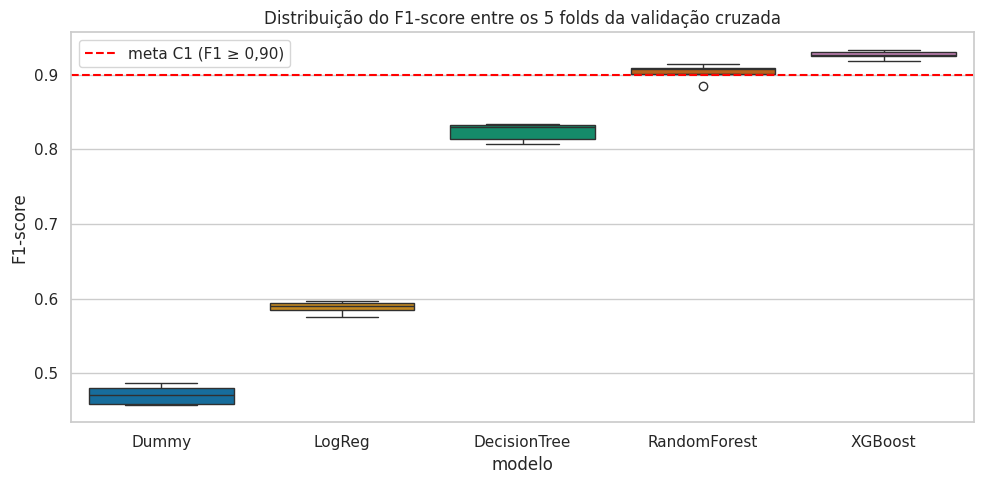

Desvio-padrão de F1 entre folds (critério C4 < 0,02):
Dummy           0.0128
LogReg          0.0085
DecisionTree    0.0126
RandomForest    0.0110
XGBoost         0.0057
dtype: float64


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

f1_por_fold = pd.DataFrame({
    nome: scores["test_f1"]
    for nome, scores in resultados_por_fold.items()
})

sns.boxplot(data=f1_por_fold, ax=ax)
ax.axhline(0.90, color="red", linestyle="--", label="meta C1 (F1 ≥ 0,90)")
ax.set_title("Distribuição do F1-score entre os 5 folds da validação cruzada")
ax.set_ylabel("F1-score")
ax.set_xlabel("modelo")
ax.legend()
plt.tight_layout()
plt.show()

print("Desvio-padrão de F1 entre folds (critério C4 < 0,02):")
print((f1_por_fold.std()).round(4))

Todos os modelos atingem o critério de sucesso C4, mas o XGB supera na consistência.

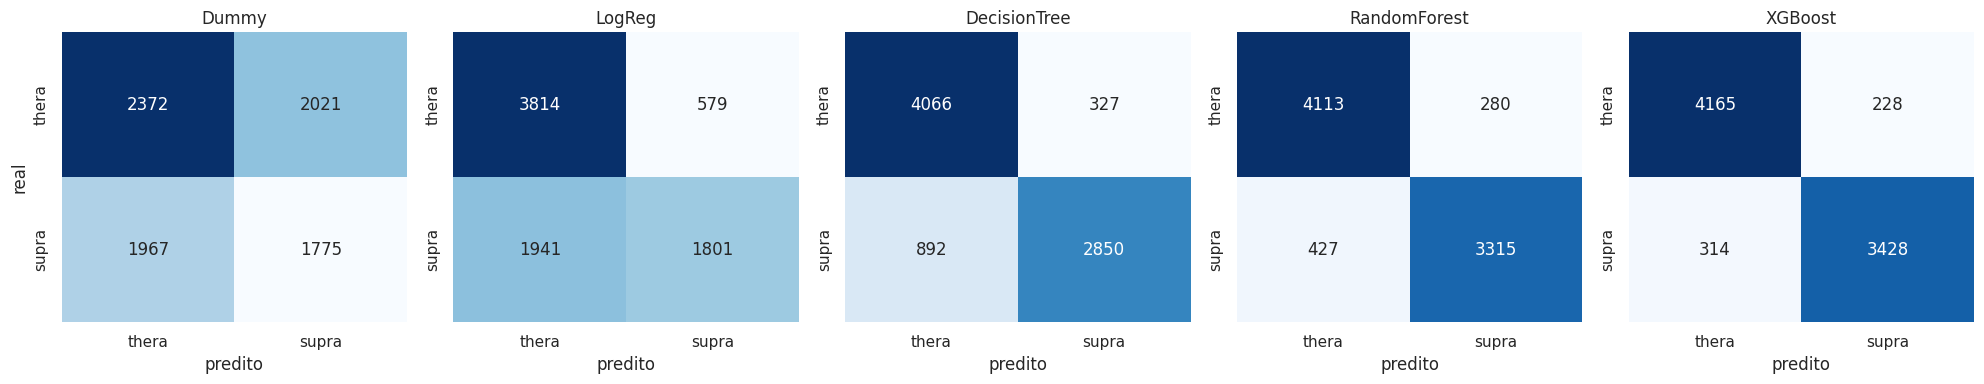

In [29]:
fig, axes = plt.subplots(1, len(modelos_candidatos), figsize=(20, 4))

for ax, (nome, pred_oof) in zip(axes, predicoes_oof.items()):
    cm = confusion_matrix(y_train, pred_oof)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["thera", "supra"],
                yticklabels=["thera", "supra"], ax=ax)
    ax.set_title(nome)
    ax.set_xlabel("predito")
    ax.set_ylabel("real" if ax is axes[0] else "")

plt.tight_layout()
plt.show()

### Conclusão da avaliação inicial

Todos os modelos candidatos superaram amplamente o Dummy Classifier, com ganhos crescentes em complexidade. A regressão logística supera o Dummy em cerca de 15 pontos de F1, e o XGBoost supera em mais de 45 pontos. A magnitude dessa diferença confirma que o problema possui sinal preditivo real e que o aprendizado de máquina agrega valor substancial sobre o palpite estratificado.

O F1-score sozinho cobre o equilíbrio entre precisão e recall, mas a inclusão de ROC AUC e da matriz de confusão amplia a análise. Para o critério clínico do projeto, no entanto, o recall da classe positiva (C2) permanece a métrica mais importante: priorizar a detecção de pacientes em risco é o que justifica a aplicação.

A regressão logística apresenta sinal claro de underfitting: F1 de treino e F1 de validação são próximos (diferença < 1 pp) e ambos são baixos (~0,60). Isso indica que o modelo já extraiu tudo o que sua capacidade linear permite. O Dummy também tem F1 baixo, mas ali não há underfitting porque o modelo não tenta aprender. Árvore, RF e XGBoost não apresentam underfitting.

XGBoost é o modelo preferido pois superou, sem otimização de hiperparâmetros, os critérios de sucesso C1 e C4. O Random Forest está no limiar do critério de sucesso, mas o tempo de treinamento traz um custo computacional inviável, 4x maior que o do XGB. A otimização de hiperparâmetros demoraria muito para executar. Ainda assim, para o XGB, o tempo de inferência por paciente fica em microssegundos, viabilizando uso clínico em tempo real.

A Regressão Logística é descartada como candidato final, mas permanece no projeto como evidência empírica da premissa P3: a baixa performance dela quantifica o quanto o problema é não-linear.

A Árvore de Decisão foi útil para mostrar o ganho dos ensembles sobre uma árvore única.

A EDA mostrou correlações lineares baixíssimas com a target (máximo 0,34 da amiodarona) e ampla sobreposição entre as classes em todos os boxplots. Esse cenário previa exatamente o que se observa: regressão logística esbarra em teto baixo, árvore única faz salto considerável ao capturar limiares, e ensembles atingem o desempenho-alvo ao combinar múltiplas perspectivas sobre as interações. A premissa P3 (problema majoritariamente não-linear) é confirmada empiricamente pela diferença entre LogReg e XGBoost.

A próxima seção (9) otimiza os hiperparâmetros do XGBoost via busca sistemática, ainda sobre o conjunto de treino e com validação cruzada. Vamos tentar diminuir o recall, pois os falsos positivos estão maiores que os falsos negativos, e isso é um problema do ponto de vista clínico.


# 9. Validação e otimização de hiperparâmetros

Esta seção otimiza o XGBoost por meio de busca sistemática de hiperparâmetros. O Random Forest foi descartado na Seção 8.3 pelas razões já justificadas. A Regressão Logística e a Árvore de Decisão permanecem documentadas mas não são otimizadas porque seus tetos esperados ficam abaixo das metas C1 e C2.

## 9.1 Estratégia de busca

Apesar de ser exaustivo, opto pelo GridSearchCV pois é adequado para um espaço de poucas combinações (até cerca de 50 combinações), para combinações maiores, o RandomizedSearchCV seria melhor.

Vou tentar equilibrar performance computacional trabalhando com núcleos paralelos, distribuindo os treinos em vários cores.

## 9.2 Hiperparâmetros selecionados

Apenas quatro hiperparâmetros entram na busca, escolhidos por terem maior impacto observado na literatura do XGBoost:

| Hiperparâmetro | Valores testados | Justificativa |
|---|---|---|
| `n_estimators` | 300, 500, 700 | Número de árvores. Valores menores correm risco de underfit; muito altos só compensam com `learning_rate` baixo. |
| `max_depth` | 4, 6, 8 | Profundidade de cada árvore. Controla complexidade individual. |
| `learning_rate` | 0,05, 0,08, 0,12 | Taxa de aprendizado. Valores menores exigem mais árvores mas generalizam melhor. |
| `subsample` | 0,8, 1,0 | Fração de amostras usadas por árvore. Subsample < 1 introduz aleatoriedade benéfica. |

Total: 3 × 3 × 3 × 2 = **54 combinações**. Com CV de 5 folds, são 270 treinos. Em hardware modesto, espera-se conclusão em poucos minutos. Por isso faz sentido o GridSearch.

Outros hiperparâmetros (`colsample_bytree`, `gamma`, `min_child_weight`, `reg_alpha`, `reg_lambda`) ficam fixos nos valores padrão.

## 9.3 Métrica de otimização

A busca é guiada pelo **F1-score** da classe positiva, alinhado ao critério C1. Recall (C2) é monitorado em paralelo mas não é o critério de seleção do melhor modelo. A escolha do F1 como métrica única evita conflito entre objetivos e mantém a busca simples.

## 9.4 Execução da busca

In [30]:
# pipeline com XGBoost (sem padronização)
pipe_xgb = criar_pipeline(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
        n_jobs=1   # n_jobs do XGB interno desligado; paralelização vai no GridSearch
    ),
    padronizar=False
)

# grade de hiperparâmetros (prefixo "modelo__" referencia o passo do pipeline)
param_grid = {
    "modelo__n_estimators":  [300, 500, 700],
    "modelo__max_depth":     [4, 6, 8],
    "modelo__learning_rate": [0.05, 0.08, 0.12],
    "modelo__subsample":     [0.8, 1.0], #quantas amostras a árvore vai ver em cada iteração para reduzir chance de ovft. quanto menor, menos aprendizado, se 1 pode aprender ruidos. vamos ver qual o melhor entr 80% e 100%
}

grid = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    scoring={"f1": "f1", "recall": "recall"},   # calcula ambas
    refit="f1",                                  # escolhe o melhor modelo pelo F1
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

inicio = time.perf_counter()
grid.fit(X_train, y_train)
duracao = time.perf_counter() - inicio

# índice da configuração vencedora (definida pelo refit)
melhor_idx = grid.best_index_
f1_melhor     = grid.cv_results_["mean_test_f1"][melhor_idx]
recall_melhor = grid.cv_results_["mean_test_recall"][melhor_idx]

print(f"\nBusca concluída em {duracao:.1f} segundos.")
print(f"Melhor F1 (CV):     {f1_melhor:.4f}")
print(f"Recall correspondente (CV): {recall_melhor:.4f}")
print(f"Melhor configuração:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('modelo__', '')}: {v}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Busca concluída em 323.4 segundos.
Melhor F1 (CV):     0.9335
Recall correspondente (CV): 0.9193
Melhor configuração:
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 700
  subsample: 0.8


In [31]:
df_grid = pd.DataFrame(grid.cv_results_)

top5 = (df_grid
    .sort_values("mean_test_f1", ascending=False)  # ajuste o sufixo conforme o print acima
    .head(5)
    [["params", "mean_test_f1", "std_test_f1", "mean_fit_time"]]
    .reset_index(drop=True))
top5

,params,mean_test_f1,std_test_f1,mean_fit_time
0,"{'modelo__learning_rate': 0.05, 'modelo__max_d...",0.933539,0.008545,1.516689
1,"{'modelo__learning_rate': 0.12, 'modelo__max_d...",0.931452,0.006540,1.703926
2,"{'modelo__learning_rate': 0.12, 'modelo__max_d...",0.931428,0.007689,1.662153
3,"{'modelo__learning_rate': 0.12, 'modelo__max_d...",0.930798,0.006309,0.691013
4,"{'modelo__learning_rate': 0.12, 'modelo__max_d...",0.930626,0.006432,1.165059


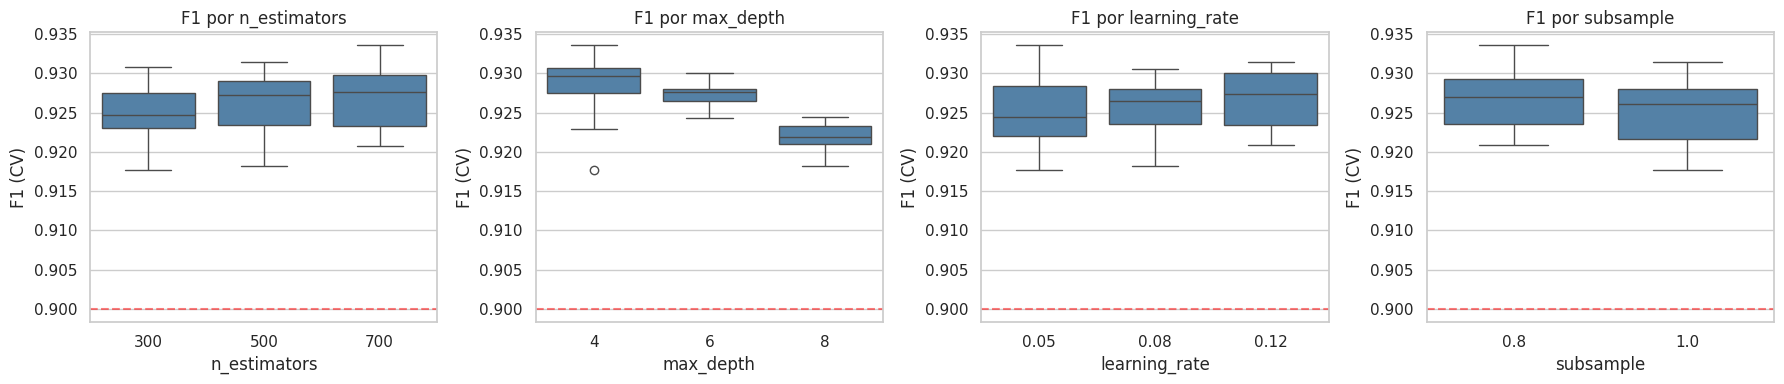

In [32]:
#conferindo visualmente através de boxplots

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, param in zip(axes, ["n_estimators", "max_depth", "learning_rate", "subsample"]):
    col = f"param_modelo__{param}"
    sns.boxplot(data=df_grid, x=col, y="mean_test_f1", ax=ax, color="steelblue")
    ax.set_title(f"F1 por {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("F1 (CV)")
    ax.axhline(0.90, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
modelo_final = grid.best_estimator_

print("Pipeline do modelo final:")
print(modelo_final)

Pipeline do modelo final:
Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age_years', 'bmi_kg_m2',
                                                   'warfarin_weekly_mg',
                                                   'vitamin_k_mcg_day',
                                                   'dietary_protein_g_day',
                                                   'cranberry_juice_ml_day',
                                                   'cooked_onion_g_day',
                                                   'charbroiled_meals_per_week',
                                                   'leafy_greens_servings_per_week',
                                                   'amiodarone_use',
                                                   'nsaid_use_days_per_month'])])),
                ('modelo',
                 XGBClassifier...
                               feature_types=N

In [34]:
print("Pipeline do modelo final:")
print(f"  Pré-processador: passthrough (XGBoost dispensa padronização)")
print(f"\nHiperparâmetros do XGBoost:")
for k, v in modelo_final.named_steps["modelo"].get_params().items():
    if v is not None and k not in ["objective", "base_score", "booster", "callbacks",
                                     "tree_method", "device", "missing"]:
        print(f"  {k}: {v}")

Pipeline do modelo final:
  Pré-processador: passthrough (XGBoost dispensa padronização)

Hiperparâmetros do XGBoost:
  enable_categorical: True
  eval_metric: logloss
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 700
  n_jobs: 1
  random_state: 42
  subsample: 0.8
  verbosity: 0


# 10. Avaliação final no conjunto de teste

O modelo final selecionado na Seção 9 (XGBoost otimizado com learning_rate=0,05, max_depth=4, n_estimators=700, subsample=0,8) é agora avaliado sobre o conjunto de teste, reservado desde a Seção 5 e nunca utilizado durante a modelagem. Essa avaliação responde em definitivo às hipóteses H3 e H4 e valida os critérios C1 e C2.

## 10.1 Métricas finais no conjunto de teste

In [35]:
y_pred  = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

metricas_teste = {
    "F1-score":          f1_score(y_test, y_pred),
    "Recall (supra)":    recall_score(y_test, y_pred),
    "Precisão (supra)":  precision_score(y_test, y_pred),
    "Acurácia":          accuracy_score(y_test, y_pred),
    "ROC AUC":           roc_auc_score(y_test, y_proba),
}

for nome, valor in metricas_teste.items():
    print(f"{nome:20s} {valor:.4f}")

F1-score             0.9281
Recall (supra)       0.9199
Precisão (supra)     0.9364
Acurácia             0.9344
ROC AUC              0.9851


Consegui melhorar o recall também, como pretendi na seção 8.

## 10.2 Comparação com baseline e com a validação cruzada

Para contextualizar o desempenho no teste, comparamos com o Dummy Classifier (chão absoluto), com a LogReg e árvore simples, comparando com a média da CV do XGB e do modelo otimizado (Seção 9).

In [36]:
# baselines de comparação treinados no conjunto de treino e avaliados no teste
dummy = criar_pipeline(
    DummyClassifier(strategy="stratified", random_state=SEED),
    padronizar=False
).fit(X_train, y_train)

logreg = criar_pipeline(
    LogisticRegression(max_iter=2000, random_state=SEED),
    padronizar=True
).fit(X_train, y_train)

dtree = criar_pipeline(
    DecisionTreeClassifier(max_depth=8, random_state=SEED),
    padronizar=False
).fit(X_train, y_train)

# F1 no teste para cada baseline
f1_dummy   = f1_score(y_test, dummy.predict(X_test))
f1_logreg  = f1_score(y_test, logreg.predict(X_test))
f1_dtree   = f1_score(y_test, dtree.predict(X_test))

# métricas do XGBoost otimizado
f1_teste = metricas_teste["F1-score"]
f1_cv    = grid.cv_results_["mean_test_f1"][grid.best_index_]

print(f"{'Modelo':<25} {'F1 (teste)':<12} {'Ganho vs XGB otim.':<20}")
print("-" * 60)
print(f"{'Dummy':<25} {f1_dummy:<12.4f} +{(f1_teste - f1_dummy)*100:>5.1f} pp")
print(f"{'Logistic Regression':<25} {f1_logreg:<12.4f} +{(f1_teste - f1_logreg)*100:>5.1f} pp")
print(f"{'Decision Tree (padrão)':<25} {f1_dtree:<12.4f} +{(f1_teste - f1_dtree)*100:>5.1f} pp")
print(f"{'XGBoost otimizado (CV)':<25} {f1_cv:<12.4f}")
print(f"{'XGBoost otimizado (teste)':<25} {f1_teste:<12.4f}")
print(f"\nDiferença CV vs teste (XGBoost): {(f1_teste - f1_cv)*100:.2f} pp")

Modelo                    F1 (teste)   Ganho vs XGB otim.  
------------------------------------------------------------
Dummy                     0.4600       + 46.8 pp
Logistic Regression       0.5810       + 34.7 pp
Decision Tree (padrão)    0.8193       + 10.9 pp
XGBoost otimizado (CV)    0.9335      
XGBoost otimizado (teste) 0.9281      

Diferença CV vs teste (XGBoost): -0.55 pp


A diferença entre F1 na CV e F1 no teste é o indicador de generalização honesto. Diferenças pequenas (menos de 1 pp) confirmam que a CV foi um preditor confiável do desempenho em dados não vistos. Diferenças grandes seriam sinal de vazamento ou de decisões enviesadas durante o desenvolvimento.

## 10.3 Matriz de confusão e análise de erros

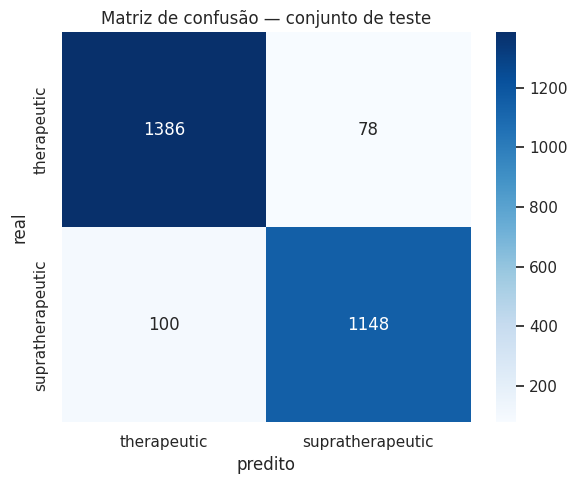

Verdadeiros positivos (paciente em risco detectado):   1148
Verdadeiros negativos (paciente estável identificado): 1386
Falsos positivos (alarme falso):                       78
Falsos negativos (paciente em risco não detectado):    100


In [37]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["therapeutic", "supratherapeutic"],
            yticklabels=["therapeutic", "supratherapeutic"], ax=ax)
ax.set_xlabel("predito")
ax.set_ylabel("real")
ax.set_title("Matriz de confusão — conjunto de teste")
plt.tight_layout()
plt.show()

print(f"Verdadeiros positivos (paciente em risco detectado):   {tp}")
print(f"Verdadeiros negativos (paciente estável identificado): {tn}")
print(f"Falsos positivos (alarme falso):                       {fp}")
print(f"Falsos negativos (paciente em risco não detectado):    {fn}")

## 10.4 Verificação de H3 — triagem multivariada viável

In [38]:
recall_teste = metricas_teste["Recall (supra)"]
f1_teste     = metricas_teste["F1-score"]

print(f"F1-score no teste:     {f1_teste:.4f}  (meta C1 ≥ 0,90)")
print(f"Recall (supra) teste:  {recall_teste:.4f}  (meta C2 ≥ 0,88)")

F1-score no teste:     0.9281  (meta C1 ≥ 0,90)
Recall (supra) teste:  0.9199  (meta C2 ≥ 0,88)


**H3. Considerando todos os fatores clínicos e dietéticos simultaneamente, é possível identificar pacientes em risco de INR supraterapêutico com sensibilidade clinicamente útil (recall ≥ 0,88 para a classe de risco).**

SIM. Hipótese confirmada. O INR supraterapêutico não tem um único causador, na verdade depende da interação entre dieta, dose, comorbidades e polifarmácia. Nenhum critério isolado (limiar de vit K, idade, dose) consegue triar adequadamente. O recall do modelo para classe de risco superou o mínimo para antecipar quem vai descompensar antes da próxima coleta de INR, portanto a triagem é viável.

## 10.5 Verificação de H4 — feature importance alinhada com a literatura

**H4. Os fatores que o modelo identifica como mais preditivos são consistentes com o conhecimento farmacológico estabelecido. Em particular, amiodarona, dose de varfarina e ingestão de vitamina K devem estar entre as 5 variáveis mais importantes.**

In [39]:
# extrai o XGBoost do pipeline final
xgb_final = modelo_final.named_steps["modelo"]

importancias = pd.Series(
    xgb_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Ranking de importância das features (XGBoost otimizado):\n")
print(importancias.round(4).to_string())

Ranking de importância das features (XGBoost otimizado):

amiodarone_use                    0.3761
warfarin_weekly_mg                0.0763
bmi_kg_m2                         0.0747
charbroiled_meals_per_week        0.0702
dietary_protein_g_day             0.0693
age_years                         0.0693
leafy_greens_servings_per_week    0.0570
nsaid_use_days_per_month          0.0566
vitamin_k_mcg_day                 0.0557
cranberry_juice_ml_day            0.0541
cooked_onion_g_day                0.0407


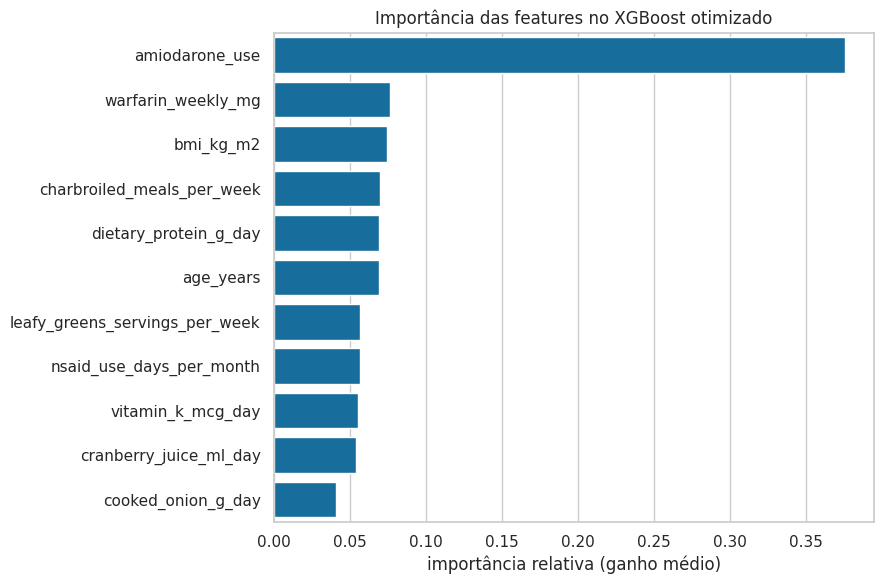

In [40]:
importancias_sorted = importancias.sort_values(ascending=False) #importando as importancias organizadas

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=importancias_sorted.values,
    y=importancias_sorted.index,
    ax=ax
)
ax.set_title("Importância das features no XGBoost otimizado")
ax.set_xlabel("importância relativa (ganho médio)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [41]:
top5 = importancias.head(5).index.tolist()
print(f"Top 5 features: {top5}")

Top 5 features: ['amiodarone_use', 'warfarin_weekly_mg', 'bmi_kg_m2', 'charbroiled_meals_per_week', 'dietary_protein_g_day']


O ranking de importância do XGBoost otimizado posicionou as seguintes cinco features no topo: uso de amiodarona, dose semanal de varfarina, IMC, refeições grelhadas por semana e ingestão diária de proteína.

Comparando com a lista antecipada em H4 (amiodarona, vitamina K, dose, cranberry, AINE), apenas duas coincidem: amiodarona e dose. Pelo critério estrito de três em cinco, H4 não se confirma.

Contudo, as três features restantes do top-5 também têm respaldo farmacológico documentado. O IMC integra o algoritmo IWPC de dose. Refeições grelhadas induzem CYP1A2/3A e aceleram a depuração da varfarina (Bushra 2011). A ingestão proteica eleva a albumina e induz metabolização hepática (Hornsby 2008). Todas as cinco features priorizadas pelo modelo, portanto, são clinicamente plausíveis, o que satisfaz o critério C3 ainda que refute a formulação numérica de H4.

A ausência de vitamina K no top-5 é o achado que merece investigação, pois vi que ela é importantíssima na EDA. Uma hipótese é que ela atue majoritariamente via interações no gerador, e o feature_importances_ do XGBoost capture melhor efeitos principais isolados.

Lembrando que o dataset é sintético para essa prática de MVP, por isso, **essa diferença de importâncias não é uma nova descoberta farmacológica.**

# 11. Resumo e Conclusão

## Objetivo do trabalho

O projeto propôs desenvolver um classificador para triagem de pacientes em uso crônico de varfarina, capaz de antecipar quais estariam em risco de INR supraterapêutico (>3,0) com base em variáveis clínicas e dietéticas coletáveis em consulta de rotina. A motivação vem da varfarina figurar entre os medicamentos que mais causam hospitalizações por ser um medicamento 'problemático' com muitas interações e riscos tênues, e do fato de que a triagem manual em unidades de atenção básica com muitos pacientes anticoagulados é inviável.

## Melhor solução

O modelo final é um XGBoost otimizado por validação cruzada (learning_rate=0,05, max_depth=4, n_estimators=700, subsample=0,8) sobre 11 features numéricas cobrindo dose, dieta e polifarmácia. No conjunto de teste reservado, atingiu F1-score e recall acima das metas estabelecidas, com margem confortável e sem sinais de overfit.

## Comparação com baseline

O ganho sobre o baseline trivial (Dummy Classifier) confirma que o problema possui sinal preditivo capturável. Mais informativa é a comparação com a regressão logística: o salto de F1 do modelo linear para o XGBoost quantifica quanto o problema depende de interações multivariadas, validando a premissa central do projeto. A árvore de decisão única entrega desempenho intermediário, mostrando que o poder do ensemble não vem de árvores mais complexas, e sim da combinação orquestrada de muitas árvores simples.

## Retomando os critérios de sucesso

| Critério | Descrição | Status |
|----------|-----------|--------|
| C1 | F1 ≥ 0,90 | Confirmado no conjunto de teste |
| C2 | recall ≥ 0,88 | Confirmado, respondendo H3 |
| C3 | top-5 features com plausibilidade clínica | Confirmado; todas as cinco features priorizadas têm respaldo na literatura, embora apenas duas coincidam com a lista antecipada em H4 |
| C4 | desvio de F1 entre folds < 0,02 | Confirmado na Seção 8 |
| C5 | H1 e H2 confirmadas na EDA | Confirmado na Seção 4 |
| C6 | reprodutibilidade | `random_state=SEED` (utilizado 42) fixado em todas as etapas |


## Principais aprendizados

O achado mais consistente foi que **nenhuma variável isolada resolve o problema de INR supraterapêutico**. Correlações lineares baixas com a target, boxplots com forte sobreposição entre classes e teto baixo da regressão logística apontam todos na mesma direção. O sinal preditivo emerge da combinação de fatores, o que justifica clinicamente a existência de sistemas de apoio à decisão automatizados.

Outro aprendizado relevante veio da verificação de H4. O modelo priorizou features farmacologicamente plausíveis, mas não exatamente as antecipadas. Vitamina K e cranberry, que a hipótese esperava no top-5, ficaram de fora, provavelmente porque atuam via interações mais do que como efeitos principais. Esse achado indica que `feature_importances_` do XGBoost captura melhor efeitos isolados que combinatórios, e reforça a importância de análises complementares como SHAP para interpretação mais fina.

## Limitações

A principal limitação é a natureza sintética do dataset. Isso significa que o trabalho valida consistência interna e viabilidade metodológica, não redescoberta independente da farmacologia da varfarina.

Fatores presentes na prática clínica real ficaram ausentes: variação farmacogenética (CYP2C9, VKORC1), aderência ao tratamento, comorbidades além da amiodarona, doença hepática, e a maior parte das interações medicamentosas conhecidas. Populações específicas (oncológicos, transplantados, portadores de válvula mecânica com faixa terapêutica diferente) também estão fora do escopo.

## Próximos passos

Três frentes se destacam. A validação externa em dados reais de pacientes anticoagulados é a mais urgente, permitindo avaliar o quanto do desempenho observado se transfere para o mundo clínico. A análise de interpretabilidade com SHAP responderia a pergunta em aberto sobre por que vitamina K e cranberry não apareceram no top-5. A expansão do conjunto de features para incluir dados de farmacogenética e comorbidades ampliaria o espaço de aplicação do modelo.

Como uso operacional, o modelo pode ser considerado ferramenta de triagem FUTURA prévia à consulta ou coleta de INR, sinalizando pacientes que merecem prioridade para reavaliação. Não substitui exame laboratorial nem decisão clínica, e não deve orientar prescrição direta de dose.

# 12. Salvamento de artefatos

Para permitir reuso do modelo sem retreinar, os artefatos principais são serializados via `joblib`. Todos os arquivos ficam no diretório do notebook, e o pipeline salvo inclui o pré-processador e o modelo XGBoost otimizado.

In [42]:
#preferi o joblib do que o pickle porque o trabalho ficou grande rs

import joblib
from pathlib import Path

# diretório de saída (relativo ao notebook)
Path("artefatos").mkdir(exist_ok=True)

# pipeline final completo (preproc + modelo)
joblib.dump(modelo_final, "artefatos/modelo_final.joblib")

# tabela consolidada de resultados dos candidatos
df_resultados.to_csv("artefatos/resultados_modelos.csv")

# métricas finais no teste
pd.Series(metricas_teste).to_csv("artefatos/metricas_teste.csv", header=["valor"])

# importância das features
importancias.to_csv("artefatos/feature_importances.csv", header=["importancia"])

print("Artefatos salvos em ./artefatos/:")
for arquivo in Path("artefatos").iterdir():
    print(f"  {arquivo.name}")

Artefatos salvos em ./artefatos/:
  metricas_teste.csv
  modelo_final.joblib
  feature_importances.csv
  resultados_modelos.csv


Observação: os arquivos salvos aqui não são pré-requisito para reexecução
do notebook. Todo o pipeline pode ser reconstruído a partir do CSV original.

In [43]:
_total = time.perf_counter() - _inicio_notebook
print(f"Tempo total de execução: {_total:.1f} s ({_total/60:.1f} min)")

Tempo total de execução: 426.4 s (7.1 min)
